In [1]:
 # =============================================================================
# STEP 1 : DATASET LOADING AND INITIAL COPY CREATION
# =============================================================================
#
# Objective:
# Load the CKD Risk Progression dataset and create a working copy
# for further analysis.
#
# =============================================================================

import pandas as pd
import numpy as np

# Correct method name: read_csv (with an underscore)
Data = pd.read_csv("D:\\project\\data\\raw\\CKD_Risk_Progression_Dataset_2026.csv")

# =============================================================================
# STEP 2 : CREATE USABLE DATASET COPY
# =============================================================================

data = Data.copy()

# =============================================================================
# STEP 3 : DATASET DIMENSION AND COLUMN INSPECTION
# =============================================================================

#GETTING THE SHAPE & COLUMNS OF THE DATASET
print(data.shape)
print(data.columns.tolist())


# =============================================================================
# END OF STEP 3 : DATASET LOADING AND INITIAL INSPECTION COMPLETED
# =============================================================================

(200000, 82)
['Patient_ID', 'Age', 'Sex', 'Ethnicity', 'Country', 'Residence_Type', 'Education_Level', 'Socioeconomic_Status', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Body_Fat_Percentage', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Exercise_Hours_Per_Week', 'Daily_Steps', 'Water_Intake_L', 'Sodium_Intake_mg', 'Fast_Food_Frequency_Per_Week', 'Sleep_Duration_Hours', 'Stress_Level', 'Diabetes', 'Hypertension', 'Cardiovascular_Disease', 'Heart_Failure', 'Hyperlipidemia', 'Kidney_Stones', 'Recurrent_UTI', 'Autoimmune_Disease', 'Family_History_CKD', 'Obesity', 'Heart_Rate', 'Respiratory_Rate', 'Oxygen_Saturation', 'Systolic_BP', 'Diastolic_BP', 'Blood_Pressure_Category', 'Serum_Creatinine', 'eGFR', 'Blood_Urea_Nitrogen', 'Albumin', 'Urine_ACR', 'Albuminuria_Category', 'Urine_Protein', 'HbA1c', 'Fasting_Glucose', 'Hemoglobin', 'Sodium', 'Potassium', 'Calcium', 'Phosphorus', 'Uric_Acid', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'CRP', 'A

In [2]:
# =============================================================================
# STEP 4 : UNDERSTANDING DATA TYPES AND DATAFRAME DISPLAY
# =============================================================================
#
# Objective:
# Inspect the data types of all variables and display the dataset.
#
# =============================================================================

#UNDERSTANDING DATATYPES
data.dtypes
display(data)


# =============================================================================
# END OF STEP 4 : DATA TYPE INSPECTION AND DATAFRAME DISPLAY COMPLETED
# =============================================================================

# =============================================================================
# STEP 5 : MISSING VALUES AND DUPLICATE VALUE CHECK
# =============================================================================
#
# Objective:
# Identify missing values and duplicate records present in the dataset.
#
# =============================================================================

#CHECKING MISSING VALUES
data.isna().sum()

#CHECKING DUPLICATE VALUES
data.duplicated().sum()


# =============================================================================
# END OF STEP 5 : MISSING VALUE AND DUPLICATE CHECK COMPLETED
# =============================================================================

,Patient_ID,Age,Sex,Ethnicity,Country,Residence_Type,Education_Level,Socioeconomic_Status,Height_cm,Weight_kg,...,Annual_Checkups,Health_Insurance,Annual_Household_Income_USD,Annual_Medical_Cost_USD,Employment_Status,CKD,CKD_Stage,Kidney_Failure_Risk,Dialysis_Required,Hospitalization_Risk
0,1,53,Female,Asian,UK,Rural,High School,Middle,171.3,62.8,...,1,1,72700,2003,Unemployed/Retired,0,Healthy,Low,0,Low
1,2,30,Male,Other,USA,Urban,High School,Middle,180.3,115.4,...,3,1,80800,1103,Employed,0,Healthy,Low,0,Low
2,3,61,Female,White,USA,Rural,Some College,High,171.1,62.6,...,0,1,142300,3285,Employed,0,Healthy,Low,0,Low
3,4,64,Female,Hispanic,Other,Rural,Some College,Low,153.3,70.7,...,1,0,24100,12113,Employed,1,Stage 3a,Low,0,Moderate
4,5,18,Male,White,UK,Rural,Some College,Middle,174.0,79.0,...,0,0,50300,2591,Employed,0,Healthy,Low,0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,47,Female,Black,USA,Urban,Some College,High,146.1,51.0,...,2,1,136800,8333,Employed,0,Healthy,Low,0,Low
199996,199997,57,Female,White,UK,Urban,Bachelor's,High,146.7,57.9,...,0,1,130900,2444,Unemployed/Retired,0,Healthy,Low,0,Low
199997,199998,59,Female,White,Canada,Rural,High School,High,155.1,51.0,...,0,1,113100,2392,Employed,0,Healthy,Low,0,Low
199998,199999,67,Male,Asian,USA,Rural,Bachelor's,High,170.7,83.3,...,4,1,152800,7035,Employed,0,Healthy,Low,0,Low


np.int64(0)

In [3]:
# =============================================================================
# STEP 6 : CREATION OF BINARY CKD TARGET VARIABLE
# =============================================================================
#
# Objective:
# Create a binary CKD indicator variable where:
# 0 = Healthy Kidney
# 1 = Any CKD Stage
#
# =============================================================================

#CREATING CKD_Any(0:1)
data["CKD"] = (
    data["CKD_Stage"] != "Healthy"
).astype(int)


data["CKD"].value_counts()
data["CKD"].value_counts(normalize=True) * 100


# =============================================================================
# END OF STEP 6 : CKD BINARY TARGET CREATION COMPLETED
# =============================================================================

CKD
0    81.474
1    18.526
Name: proportion, dtype: float64

In [4]:
# =============================================================================
# STEP 7 : REMOVAL OF DATA LEAKAGE AND CREATION OF MODELLING DATASET
# =============================================================================
#
# Objective:
# Identify leakage variables and create independent feature (X) and target (y)
# datasets for modelling.
#
# =============================================================================

#PHASE 4:Remove Data Leakage and Create the Modelling Dataset

#Idenfiying the Kidney Markers to be used for modelling
leakage_cols = [
    "Patient_ID",

    # Kidney diagnostic markers
    "Serum_Creatinine",
    "eGFR",
    "Blood_Urea_Nitrogen",
    "Albumin",
    "Urine_ACR",
    "Albuminuria_Category",
    "Urine_Protein",
    "CKD_Stage",
    "Kidney_Failure_Risk",
    "Dialysis_Required",
    "Hospitalization_Risk",
    "ACE_Inhibitor",
    "ARB",
    "Diabetes_Medication",
    "Statin",
    "Diuretic",
    "Medication_Adherence",
    "Number_of_Medications",
    "Hospital_Visits",
    "Emergency_Visits",
    "Specialist_Visits",
    "Annual_Medical_Cost_USD",

    "HbA1c",
    "Fasting_Glucose",
    "Hemoglobin",
    "Sodium",
    "Potassium",
    "Calcium",
    "Phosphorus",
    "Uric_Acid",
    "Total_Cholesterol",
    "HDL",
    "LDL",
    "Triglycerides",
    "CRP",
    "Frailty_Index",
    "Frailty_Category"
]

print("Number of kidney markers:", len(leakage_cols))


#Splitting the training dataset into x_train and y_train
x_data = data.drop(
    columns=leakage_cols +
    [ "CKD"]
)

y_data = data["CKD"]



print(x_data.shape)
print(y_data.shape)


# =============================================================================
# END OF STEP 7 : DATA LEAKAGE REMOVAL AND MODELLING DATASET CREATION COMPLETED
# =============================================================================

Number of kidney markers: 38
(200000, 43)
(200000,)


In [5]:
# =============================================================================
# STEP 8 : FEATURE ENGINEERING AND FINAL FEATURE SELECTION
# =============================================================================
#
# Objective:
# Create clinically meaningful derived features for early CKD risk modelling
# and remove redundant variables to prepare the final feature dataset.
#
# =============================================================================


# Creating Pulse Pressure
x_data["Pulse_Pressure"] = (
    x_data["Systolic_BP"] -
    x_data["Diastolic_BP"]
)


# Creating Waist-to-Height Ratio
x_data["Waist_to_Height"] = (
    x_data["Waist_Circumference_cm"] /
    x_data["Height_cm"]
)


# Creating Lifestyle Risk Score
x_data["Lifestyle_Risk"] = (
    (x_data["Smoking_Status"] == "Current").astype(int) +
    (x_data["Alcohol_Consumption"] == "High").astype(int) +
    (x_data["Physical_Activity_Level"] == "Low").astype(int)
)


# Creating Metabolic Risk Score
x_data["Metabolic_Risk"] = (
    x_data["Diabetes"].astype(int) +
    x_data["Hypertension"].astype(int) +
    x_data["Obesity"].astype(int)
)


# Creating Cardiovascular Risk Score
x_data["CV_Risk"] = (
    x_data["Cardiovascular_Disease"].astype(int) +
    x_data["Heart_Failure"].astype(int) +
    x_data["Hyperlipidemia"].astype(int)
)


# Creating Poor Sleep Indicator
x_data["Poor_Sleep"] = (
    (x_data["Sleep_Duration_Hours"] < 6) |
    (x_data["Sleep_Duration_Hours"] > 9)
).astype(int)


print("Final Feature Count:", x_data.shape)
print("Final Feature List:", x_data.columns.tolist())


# =============================================================================
# END OF STEP 8 : FEATURE ENGINEERING AND FINAL FEATURE SELECTION COMPLETED
# =============================================================================

Final Feature Count: (200000, 49)
Final Feature List: ['Age', 'Sex', 'Ethnicity', 'Country', 'Residence_Type', 'Education_Level', 'Socioeconomic_Status', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Body_Fat_Percentage', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Exercise_Hours_Per_Week', 'Daily_Steps', 'Water_Intake_L', 'Sodium_Intake_mg', 'Fast_Food_Frequency_Per_Week', 'Sleep_Duration_Hours', 'Stress_Level', 'Diabetes', 'Hypertension', 'Cardiovascular_Disease', 'Heart_Failure', 'Hyperlipidemia', 'Kidney_Stones', 'Recurrent_UTI', 'Autoimmune_Disease', 'Family_History_CKD', 'Obesity', 'Heart_Rate', 'Respiratory_Rate', 'Oxygen_Saturation', 'Systolic_BP', 'Diastolic_BP', 'Blood_Pressure_Category', 'NSAID_Usage', 'Annual_Checkups', 'Health_Insurance', 'Annual_Household_Income_USD', 'Employment_Status', 'Pulse_Pressure', 'Waist_to_Height', 'Lifestyle_Risk', 'Metabolic_Risk', 'CV_Risk', 'Poor_Sleep']


In [6]:
display(x_data)

,Age,Sex,Ethnicity,Country,Residence_Type,Education_Level,Socioeconomic_Status,Height_cm,Weight_kg,BMI,...,Annual_Checkups,Health_Insurance,Annual_Household_Income_USD,Employment_Status,Pulse_Pressure,Waist_to_Height,Lifestyle_Risk,Metabolic_Risk,CV_Risk,Poor_Sleep
0,53,Female,Asian,UK,Rural,High School,Middle,171.3,62.8,21.4,...,1,1,72700,Unemployed/Retired,40,0.450671,0,0,0,1
1,30,Male,Other,USA,Urban,High School,Middle,180.3,115.4,35.5,...,3,1,80800,Employed,44,0.578480,0,1,0,0
2,61,Female,White,USA,Rural,Some College,High,171.1,62.6,21.4,...,0,1,142300,Employed,56,0.379895,0,0,1,0
3,64,Female,Hispanic,Other,Rural,Some College,Low,153.3,70.7,30.1,...,1,0,24100,Employed,61,0.531637,0,2,1,0
4,18,Male,White,UK,Rural,Some College,Middle,174.0,79.0,26.1,...,0,0,50300,Employed,61,0.506897,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,47,Female,Black,USA,Urban,Some College,High,146.1,51.0,23.9,...,2,1,136800,Employed,46,0.484600,0,0,0,0
199996,57,Female,White,UK,Urban,Bachelor's,High,146.7,57.9,26.9,...,0,1,130900,Unemployed/Retired,50,0.544649,0,0,0,0
199997,59,Female,White,Canada,Rural,High School,High,155.1,51.0,21.2,...,0,1,113100,Employed,60,0.457769,0,0,0,0
199998,67,Male,Asian,USA,Rural,Bachelor's,High,170.7,83.3,28.6,...,4,1,152800,Employed,61,0.525483,0,1,0,0


In [7]:
# =============================================================================
# STEP 9 : IDENTIFICATION OF NUMERICAL AND CATEGORICAL FEATURES
# =============================================================================
#
# Objective:
# Separate the feature dataset into numerical and categorical variables
# for preprocessing and model development.
#
# =============================================================================

#Separate numerical and categorical columns

# Numerical features
numeric_features = x_data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical features
categorical_features = x_data.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# =============================================================================
# END OF STEP 9 : FEATURE TYPE IDENTIFICATION COMPLETED
# =============================================================================

Numerical Features:
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Body_Fat_Percentage', 'Exercise_Hours_Per_Week', 'Daily_Steps', 'Water_Intake_L', 'Sodium_Intake_mg', 'Fast_Food_Frequency_Per_Week', 'Sleep_Duration_Hours', 'Diabetes', 'Hypertension', 'Cardiovascular_Disease', 'Heart_Failure', 'Hyperlipidemia', 'Kidney_Stones', 'Recurrent_UTI', 'Autoimmune_Disease', 'Family_History_CKD', 'Obesity', 'Heart_Rate', 'Respiratory_Rate', 'Oxygen_Saturation', 'Systolic_BP', 'Diastolic_BP', 'NSAID_Usage', 'Annual_Checkups', 'Health_Insurance', 'Annual_Household_Income_USD', 'Pulse_Pressure', 'Waist_to_Height', 'Lifestyle_Risk', 'Metabolic_Risk', 'CV_Risk', 'Poor_Sleep']

Categorical Features:
['Sex', 'Ethnicity', 'Country', 'Residence_Type', 'Education_Level', 'Socioeconomic_Status', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Stress_Level', 'Blood_Pressure_Category', 'Employment_Status']


C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_12828\4181343587.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x_data.select_dtypes(


In [8]:
# =============================================================================
# STEP 10 : PREPROCESSING PIPELINE CONSTRUCTION
# =============================================================================
#
# Objective:
# Build preprocessing pipelines for numerical and categorical features
# and combine them into a unified preprocessing workflow for model training.
#
# =============================================================================

#PREPROCESSOR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


# =============================================================================
# END OF STEP 10 : PREPROCESSING PIPELINE CONSTRUCTION COMPLETED
# =============================================================================

In [9]:
# =============================================================================
# STEP 11 : TRAIN-VALIDATION SPLIT AND DATA PREPROCESSING
# =============================================================================
#
# Objective:
# Split the modelling dataset into training and validation sets and
# preprocess both datasets using the previously defined preprocessing pipeline.
#
# =============================================================================

from sklearn.model_selection import train_test_split

# Split the dataset
x_train, x_valid, y_train, y_valid = train_test_split(
    x_data,
    y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

# Fit the preprocessor on the training data
x_train_processed = preprocessor.fit_transform(x_train)

# Transform the validation data
x_valid_processed = preprocessor.transform(x_valid)


# =============================================================================
# END OF STEP 11 : TRAIN-VALIDATION SPLIT AND DATA PREPROCESSING COMPLETED
# =============================================================================

# =============================================================================
# STEP 12 : CLASS BALANCING USING SMOTE
# =============================================================================
#
# Objective:
# Apply Synthetic Minority Oversampling Technique (SMOTE) to the
# preprocessed training data to address class imbalance.
#
# =============================================================================

from imblearn.over_sampling import SMOTE

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_processed,
    y_train
)


# =============================================================================
# END OF STEP 12 : SMOTE RESAMPLING COMPLETED
# =============================================================================

In [10]:
# =============================================================================
# STEP 13 : LOGISTIC REGRESSION MODEL DEVELOPMENT AND EVALUATION
# =============================================================================
#
# Objective:
# Train a Logistic Regression classifier using the SMOTE-balanced
# training dataset and evaluate its performance on the validation set.
#
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# -----------------------------------------------------------------------------
# Build Logistic Regression Model
# -----------------------------------------------------------------------------

log_model = LogisticRegression(
    max_iter=1000,
    class_weight=None,   # or "balanced" if you are NOT using SMOTE
    random_state=42
)

# -----------------------------------------------------------------------------
# Train the Model
# -----------------------------------------------------------------------------

log_model.fit(
    x_train_smote,
    y_train_smote
)

# -----------------------------------------------------------------------------
# Predict Validation Set
# -----------------------------------------------------------------------------

y_pred = log_model.predict(x_valid_processed)
y_prob = log_model.predict_proba(x_valid_processed)[:, 1]

# -----------------------------------------------------------------------------
# Performance Metrics
# -----------------------------------------------------------------------------

log_accuracy = accuracy_score(y_valid, y_pred)
log_precision = precision_score(y_valid, y_pred)
log_recall = recall_score(y_valid, y_pred)
log_f1 = f1_score(y_valid, y_pred)
log_roc_auc = roc_auc_score(y_valid, y_prob)

# -----------------------------------------------------------------------------
# Display Results
# -----------------------------------------------------------------------------

print("=" * 90)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 90)

print(f"Accuracy  : {log_accuracy:.5f}")
print(f"Precision : {log_precision:.5f}")
print(f"Recall    : {log_recall:.5f}")
print(f"F1 Score  : {log_f1:.5f}")
print(f"ROC-AUC   : {log_roc_auc:.5f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, y_pred))

print("\nClassification Report")
print(classification_report(y_valid, y_pred))

# =============================================================================
# END OF STEP 13 : LOGISTIC REGRESSION MODEL DEVELOPMENT AND EVALUATION COMPLETED
# =============================================================================

# =============================================================================
# STEP 14 : RANDOM FOREST MODEL DEVELOPMENT AND EVALUATION
# =============================================================================
#
# Objective:
# Train a Random Forest classifier using the SMOTE-balanced
# training dataset and evaluate its performance on the validation set.
#
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(x_valid_processed)
y_prob_rf = rf_model.predict_proba(x_valid_processed)[:, 1]

rf_accuracy = accuracy_score(y_valid, y_pred_rf)
rf_precision = precision_score(y_valid, y_pred_rf)
rf_recall = recall_score(y_valid, y_pred_rf)
rf_f1 = f1_score(y_valid, y_pred_rf)
rf_auc = roc_auc_score(y_valid, y_prob_rf)

# =============================================================================
# RANDOM FOREST : MODEL PERFORMANCE
# =============================================================================

print("=" * 90)
print("RANDOM FOREST RESULTS")
print("=" * 90)

print(f"Accuracy  : {rf_accuracy:.5f}")
print(f"Precision : {rf_precision:.5f}")
print(f"Recall    : {rf_recall:.5f}")
print(f"F1 Score  : {rf_f1:.5f}")
print(f"ROC-AUC   : {rf_auc:.5f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_valid, y_pred_rf))

# =============================================================================
# END OF STEP 14 : RANDOM FOREST MODEL DEVELOPMENT AND EVALUATION COMPLETED
# =============================================================================

# =============================================================================
# STEP 15 : SUPPORT VECTOR MACHINE MODEL DEVELOPMENT AND EVALUATION
# =============================================================================
#
# Objective:
# Train a Linear Support Vector Machine using the SMOTE-balanced
# training dataset and evaluate its performance on the validation set.
#
# =============================================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=10000
)

svm_model.fit(
    x_train_smote,
    y_train_smote
)

y_pred_svm = svm_model.predict(x_valid_processed)

# Used instead of predict_proba()
y_score = svm_model.decision_function(x_valid_processed)

svm_accuracy = accuracy_score(y_valid, y_pred_svm)
svm_precision = precision_score(y_valid, y_pred_svm)
svm_recall = recall_score(y_valid, y_pred_svm)
svm_f1 = f1_score(y_valid, y_pred_svm)
svm_roc_auc = roc_auc_score(y_valid, y_score)

# =============================================================================
# SUPPORT VECTOR MACHINE : MODEL PERFORMANCE
# =============================================================================

print("=" * 90)
print("LINEAR SUPPORT VECTOR MACHINE RESULTS")
print("=" * 90)

print(f"Accuracy  : {svm_accuracy:.5f}")
print(f"Precision : {svm_precision:.5f}")
print(f"Recall    : {svm_recall:.5f}")
print(f"F1 Score  : {svm_f1:.5f}")
print(f"ROC-AUC   : {svm_roc_auc:.5f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_valid, y_pred_svm))

print("\nClassification Report")
print(classification_report(y_valid, y_pred_svm))

# =============================================================================
# END OF STEP 15 : SUPPORT VECTOR MACHINE MODEL DEVELOPMENT AND EVALUATION COMPLETED
# =============================================================================

LOGISTIC REGRESSION RESULTS
Accuracy  : 0.90533
Precision : 0.68498
Recall    : 0.90526
F1 Score  : 0.77986
ROC-AUC   : 0.95242

Confusion Matrix
[[29505  3085]
 [  702  6708]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     32590
           1       0.68      0.91      0.78      7410

    accuracy                           0.91     40000
   macro avg       0.83      0.91      0.86     40000
weighted avg       0.92      0.91      0.91     40000

RANDOM FOREST RESULTS
Accuracy  : 0.93885
Precision : 0.86044
Recall    : 0.79960
F1 Score  : 0.82890
ROC-AUC   : 0.94808

Confusion Matrix
[[31629   961]
 [ 1485  5925]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     32590
           1       0.86      0.80      0.83      7410

    accuracy                           0.94     40000
   macro avg       0.91      0.89      0.90     40000
weighte

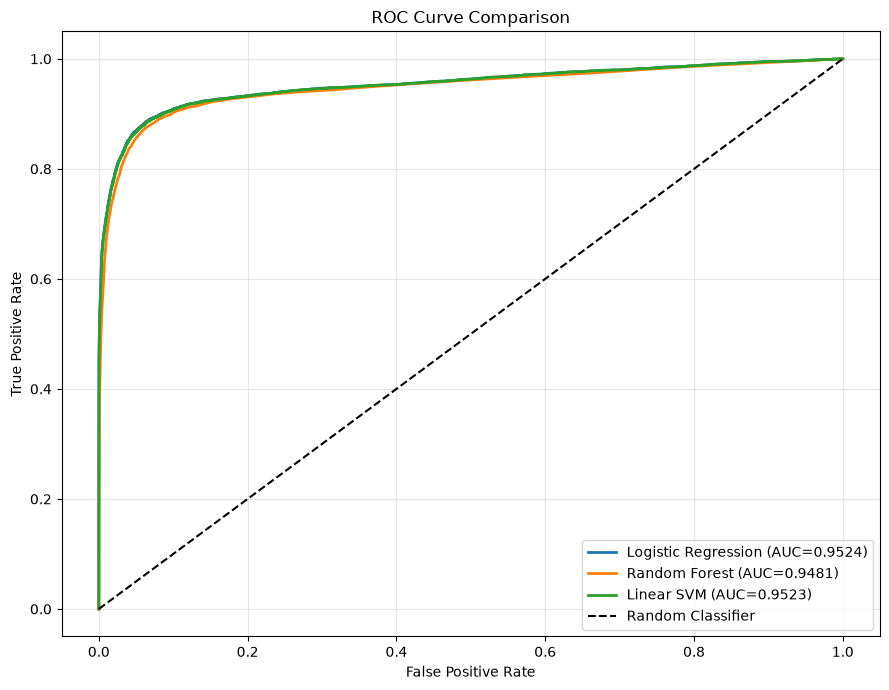

In [11]:
# =============================================================================
# STEP 19 : ROC CURVE COMPARISON
# =============================================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_valid,
    y_prob
)

auc_lr = roc_auc_score(
    y_valid,
    y_prob
)


# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_valid,
    y_prob_rf
)

auc_rf = roc_auc_score(
    y_valid,
    y_prob_rf
)


# Support Vector Machine
fpr_svm, tpr_svm, _ = roc_curve(
    y_valid,
    y_score
)

auc_svm = roc_auc_score(
    y_valid,
    y_score
)


# Plot

plt.figure(figsize=(9,7))


plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC={auc_lr:.4f})"
)


plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC={auc_rf:.4f})"
)


plt.plot(
    fpr_svm,
    tpr_svm,
    linewidth=2,
    label=f"Linear SVM (AUC={auc_svm:.4f})"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve Comparison"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()


# =============================================================================
# END OF STEP 19
# =============================================================================

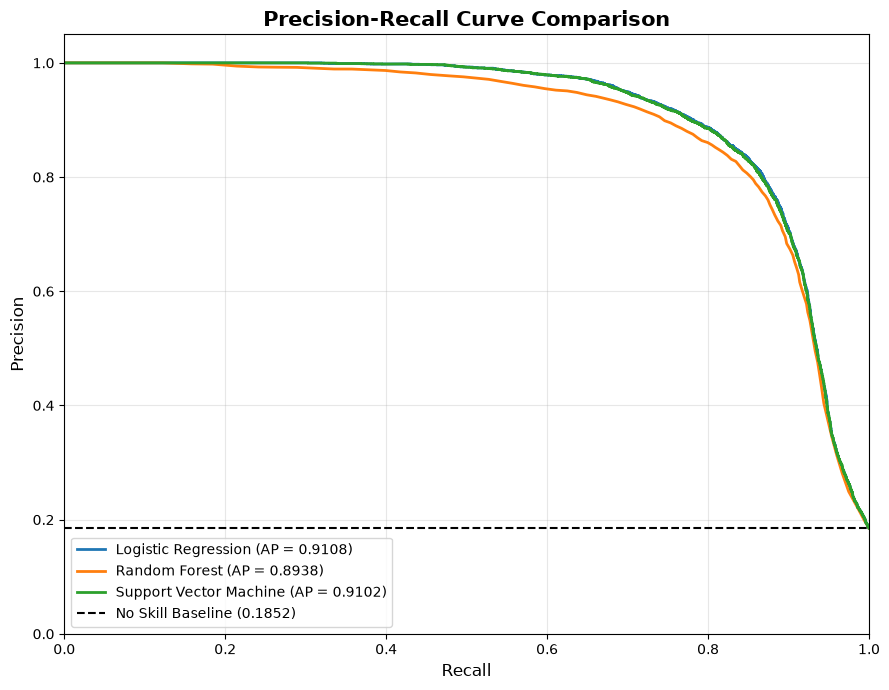

In [12]:
# =============================================================================
# STEP 20 : PRECISION-RECALL CURVE COMPARISON
# =============================================================================
#
# Objective:
# Compare the Precision-Recall curves of Logistic Regression,
# Random Forest, and Support Vector Machine in a single figure.
#
# =============================================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt


# =============================================================================
# LOGISTIC REGRESSION
# =============================================================================

precision_lr, recall_lr, _ = precision_recall_curve(
    y_valid,
    y_prob
)

ap_lr = average_precision_score(
    y_valid,
    y_prob
)


# =============================================================================
# RANDOM FOREST
# =============================================================================

precision_rf, recall_rf, _ = precision_recall_curve(
    y_valid,
    y_prob_rf
)

ap_rf = average_precision_score(
    y_valid,
    y_prob_rf
)


# =============================================================================
# SUPPORT VECTOR MACHINE
# =============================================================================

precision_svm, recall_svm, _ = precision_recall_curve(
    y_valid,
    y_score
)

ap_svm = average_precision_score(
    y_valid,
    y_score
)


# =============================================================================
# PRECISION-RECALL CURVE COMPARISON
# =============================================================================

plt.figure(figsize=(9,7))


# Logistic Regression
plt.plot(
    recall_lr,
    precision_lr,
    linewidth=2,
    label=f"Logistic Regression (AP = {ap_lr:.4f})"
)


# Random Forest
plt.plot(
    recall_rf,
    precision_rf,
    linewidth=2,
    label=f"Random Forest (AP = {ap_rf:.4f})"
)


# Support Vector Machine
plt.plot(
    recall_svm,
    precision_svm,
    linewidth=2,
    label=f"Support Vector Machine (AP = {ap_svm:.4f})"
)


# Random baseline
baseline = y_valid.mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label=f"No Skill Baseline ({baseline:.4f})"
)


# =============================================================================
# FORMATTING
# =============================================================================

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)


plt.title(
    "Precision-Recall Curve Comparison",
    fontsize=15,
    fontweight="bold"
)


plt.xlim(
    [0,1]
)

plt.ylim(
    [0,1.05]
)


plt.legend(
    loc="lower left"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# =============================================================================
# END OF STEP 20 : PRECISION-RECALL CURVE COMPARISON COMPLETED
# =============================================================================

In [13]:
# =============================================================================
# STEP 22 : LOGISTIC REGRESSION FEATURE IMPORTANCE USING ODDS RATIOS
# =============================================================================
#
# Objective:
# Interpret the Logistic Regression model by extracting feature
# coefficients, calculating odds ratios, and identifying the most
# influential risk and protective factors for CKD prediction.
#
# =============================================================================

# Feature names
feature_names = preprocessor.get_feature_names_out()

# Create coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_model.coef_[0]
})

# Calculate odds ratios
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

# Top risk factors (highest odds ratios)
top_risk = coef_df.sort_values(
    by="Odds_Ratio",
    ascending=False
)

print("Top 20 Risk Factors")
print(top_risk.head(20))

# Top protective factors (lowest odds ratios)
top_protective = coef_df.sort_values(
    by="Odds_Ratio",
    ascending=True
)

print("\nTop 20 Protective Factors")
print(top_protective.head(20))

# Save complete table
coef_df.to_csv(
    "Logistic_Coefficients_OddsRatios.csv",
    index=False
)

display(top_risk.head(20))
display(top_protective.head(20))

# =============================================================================
# END OF STEP 22 : LOGISTIC REGRESSION FEATURE IMPORTANCE USING ODDS RATIOS COMPLETED
# =============================================================================

Top 20 Risk Factors
                                              Feature  Coefficient  Odds_Ratio
0                                            num__Age     2.028435    7.602179
3                                            num__BMI     1.041915    2.834640
12                                      num__Diabetes     0.876302    2.402001
13                                  num__Hypertension     0.860746    2.364924
34                                num__Metabolic_Risk     0.614291    1.848345
28                               num__Annual_Checkups     0.412664    1.510838
37                                    cat__Sex_Female     0.348459    1.416882
33                                num__Lifestyle_Risk     0.324917    1.383916
1                                      num__Height_cm     0.249758    1.283715
74  cat__Blood_Pressure_Category_Hypertension Stage 2     0.248154    1.281658
19                            num__Autoimmune_Disease     0.198150    1.219146
75   cat__Blood_Pressure_Categor

,Feature,Coefficient,Odds_Ratio
0,num__Age,2.028435,7.602179
3,num__BMI,1.041915,2.834640
12,num__Diabetes,0.876302,2.402001
13,num__Hypertension,0.860746,2.364924
34,num__Metabolic_Risk,0.614291,1.848345
28,num__Annual_Checkups,0.412664,1.510838
37,cat__Sex_Female,0.348459,1.416882
33,num__Lifestyle_Risk,0.324917,1.383916
1,num__Height_cm,0.249758,1.283715
74,cat__Blood_Pressure_Category_Hypertension Stage 2,0.248154,1.281658


,Feature,Coefficient,Odds_Ratio
38,cat__Sex_Male,-0.743423,0.475483
72,cat__Blood_Pressure_Category_Elevated,-0.492896,0.610855
2,num__Weight_kg,-0.459916,0.631336
77,cat__Employment_Status_Employed,-0.360055,0.697638
73,cat__Blood_Pressure_Category_Hypertension Stage 1,-0.348892,0.705469
21,num__Obesity,-0.333625,0.716322
63,cat__Alcohol_Consumption_Heavy,-0.281748,0.754464
57,cat__Socioeconomic_Status_High,-0.264232,0.767795
61,cat__Smoking_Status_Former,-0.237690,0.788447
26,num__Diastolic_BP,-0.234543,0.790933


In [14]:
# =============================================================================
# STEP 23 : 5-FOLD CROSS VALIDATION - LOGISTIC REGRESSION
# =============================================================================
#
# Objective:
# Evaluate the stability and generalization performance of the
# Logistic Regression model using Stratified 5-Fold Cross Validation.
#
# SMOTE is applied ONLY to the training fold in each iteration,
# preventing data leakage.
#
# =============================================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# =============================================================================
# Common Stratified 5-Fold Cross Validation
# =============================================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_scores = cross_val_score(
    lr_pipeline,
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("=" * 90)
print("LOGISTIC REGRESSION - 5 FOLD CROSS VALIDATION")
print("=" * 90)

for i, score in enumerate(lr_scores, start=1):
    print(f"Fold {i} Accuracy : {score:.5f}")

print("-" * 90)
print(f"Mean Accuracy     : {lr_scores.mean():.5f}")
print(f"Standard Deviation: {lr_scores.std():.5f}")

# =============================================================================
# END OF STEP 23 : LOGISTIC REGRESSION CROSS VALIDATION COMPLETED
# =============================================================================


# =============================================================================
# STEP 24 : 5-FOLD CROSS VALIDATION - RANDOM FOREST
# =============================================================================
#
# Objective:
# Evaluate the robustness and generalization performance of the
# Random Forest classifier using Stratified 5-Fold Cross Validation.
#
# Random Forest is evaluated without SMOTE since it is relatively
# robust to moderate class imbalance.
#
# =============================================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_scores = cross_val_score(
    rf_pipeline,
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("=" * 90)
print("RANDOM FOREST - 5 FOLD CROSS VALIDATION")
print("=" * 90)

for i, score in enumerate(rf_scores, start=1):
    print(f"Fold {i} Accuracy : {score:.5f}")

print("-" * 90)
print(f"Mean Accuracy     : {rf_scores.mean():.5f}")
print(f"Standard Deviation: {rf_scores.std():.5f}")

# =============================================================================
# END OF STEP 24 : RANDOM FOREST CROSS VALIDATION COMPLETED
# =============================================================================



# =============================================================================
# STEP 25 : SUPPORT VECTOR MACHINE
# =============================================================================
#
# Objective:
# Evaluate the generalization capability of the Linear Support
# Vector Machine using Stratified 5-Fold Cross Validation.
#
# SMOTE is applied ONLY to the training fold in each iteration.
#
# =============================================================================

svm_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LinearSVC(
        random_state=42,
        max_iter=10000
    ))
])

from sklearn.model_selection import cross_val_score

svm_cv = cross_val_score(
    svm_model,
    x_train_processed,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(svm_cv)
print(svm_cv.mean())
print(svm_cv.std())

print("SVM CV Mean:", f"{svm_cv.mean():.5f}")
print("SVM CV STD :", f"{svm_cv.std():.5f}")

# =============================================================================
# END OF STEP 25 : SUPPORT VECTOR MACHINE CROSS VALIDATION COMPLETED
# =============================================================================

LOGISTIC REGRESSION - 5 FOLD CROSS VALIDATION
Fold 1 Accuracy : 0.90925
Fold 2 Accuracy : 0.90978
Fold 3 Accuracy : 0.90575
Fold 4 Accuracy : 0.90216
Fold 5 Accuracy : 0.90456
------------------------------------------------------------------------------------------
Mean Accuracy     : 0.90630
Standard Deviation: 0.00287
RANDOM FOREST - 5 FOLD CROSS VALIDATION
Fold 1 Accuracy : 0.94153
Fold 2 Accuracy : 0.94234
Fold 3 Accuracy : 0.94153
Fold 4 Accuracy : 0.93984
Fold 5 Accuracy : 0.94037
------------------------------------------------------------------------------------------
Mean Accuracy     : 0.94113
Standard Deviation: 0.00090
[0.94628125 0.9458125  0.946      0.9470625  0.9435    ]
0.9457312499999999
0.0011943225066957399
SVM CV Mean: 0.94573
SVM CV STD : 0.00119


TOP 20 IMPORTANT FEATURES - RANDOM FOREST


,Feature,Importance
0,num__Age,0.150065
34,num__Metabolic_Risk,0.076966
12,num__Diabetes,0.073276
13,num__Hypertension,0.055328
25,num__Systolic_BP,0.054141
76,cat__Blood_Pressure_Category_Normal,0.049813
26,num__Diastolic_BP,0.045695
5,num__Body_Fat_Percentage,0.040188
74,cat__Blood_Pressure_Category_Hypertension Stage 2,0.034672
28,num__Annual_Checkups,0.032409


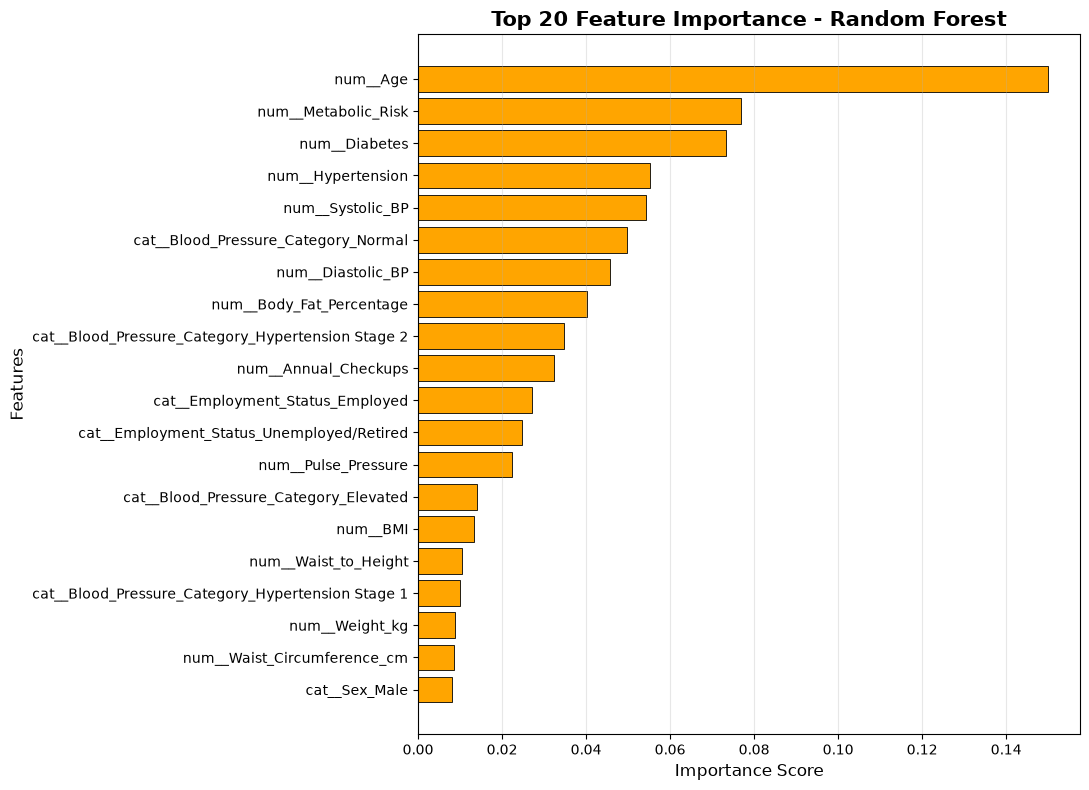



TOP 20 IMPORTANT FEATURES - LOGISTIC REGRESSION


,Feature,Coefficient,Absolute Importance
0,num__Age,2.028435,2.028435
3,num__BMI,1.041915,1.041915
12,num__Diabetes,0.876302,0.876302
13,num__Hypertension,0.860746,0.860746
38,cat__Sex_Male,-0.743423,0.743423
34,num__Metabolic_Risk,0.614291,0.614291
72,cat__Blood_Pressure_Category_Elevated,-0.492896,0.492896
2,num__Weight_kg,-0.459916,0.459916
28,num__Annual_Checkups,0.412664,0.412664
77,cat__Employment_Status_Employed,-0.360055,0.360055


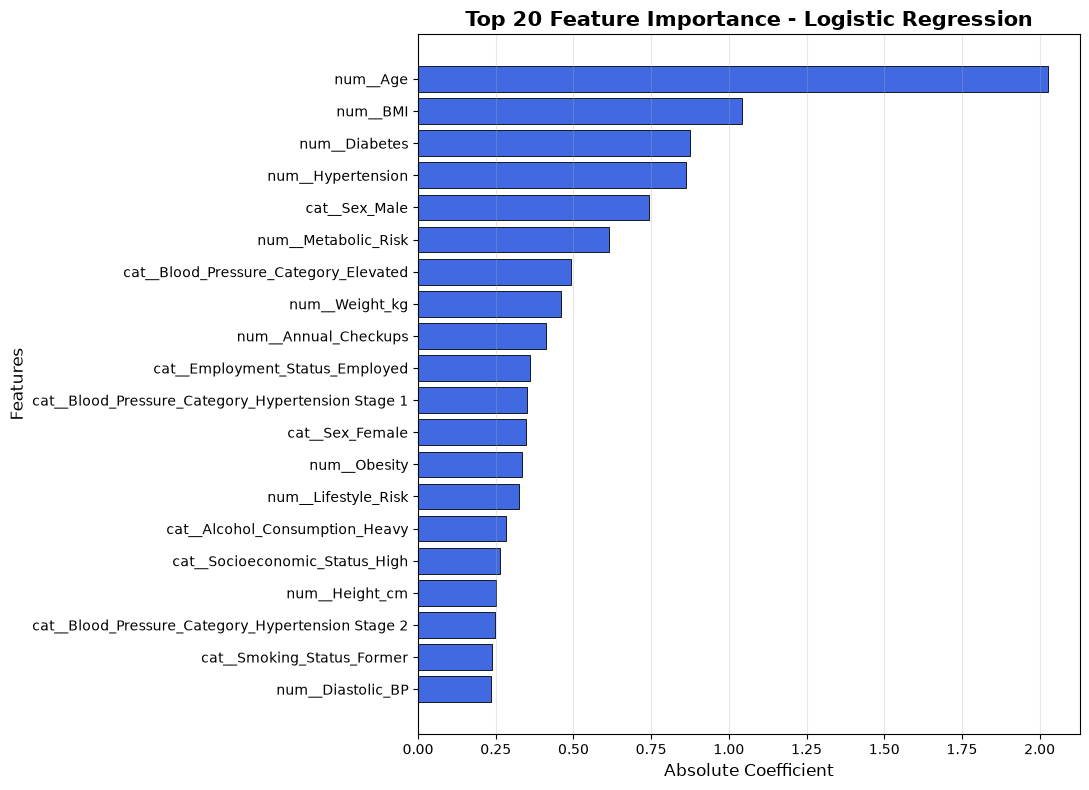



TOP 20 IMPORTANT FEATURES - SUPPORT VECTOR MACHINE


,Feature,Importance
0,num__Age,0.113232
3,num__BMI,0.052677
12,num__Diabetes,0.031575
13,num__Hypertension,0.019945
2,num__Weight_kg,0.019397
26,num__Diastolic_BP,0.010732
25,num__Systolic_BP,0.010240
21,num__Obesity,0.007675
1,num__Height_cm,0.004670
28,num__Annual_Checkups,0.004565


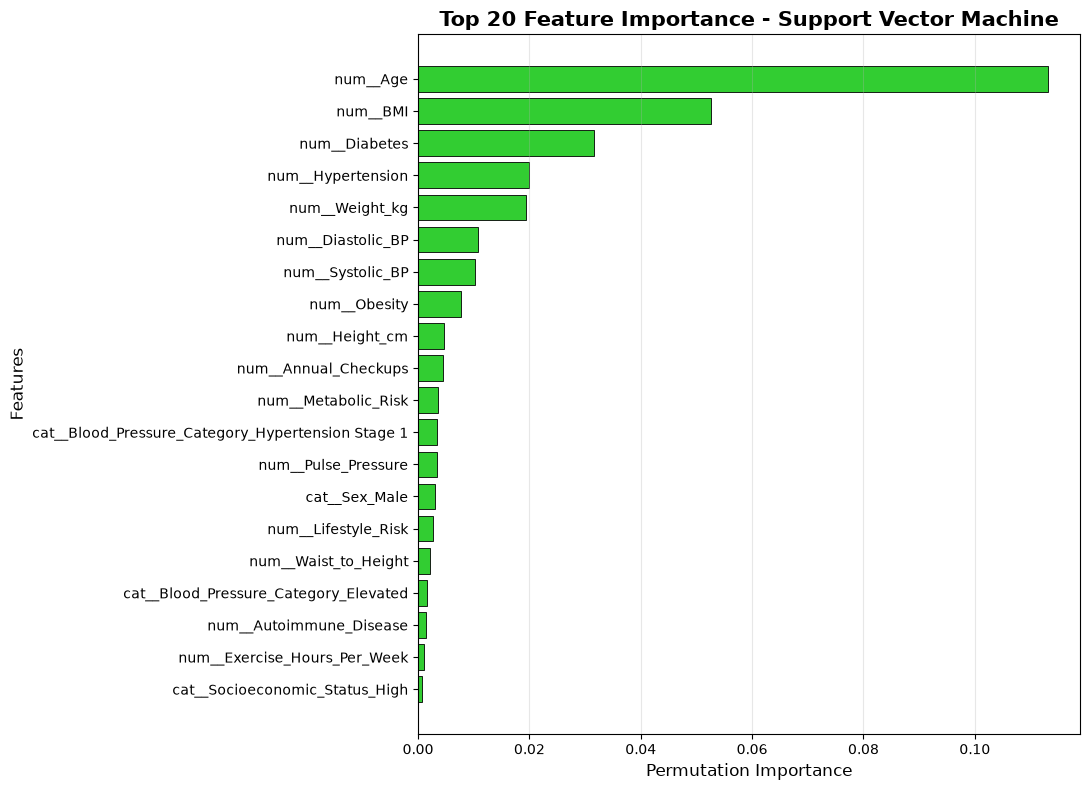



FEATURE IMPORTANCE ANALYSIS COMPLETED SUCCESSFULLY

Random Forest  : Tree-based Feature Importance
Logistic Model : Absolute Coefficient Importance
Linear SVM     : Permutation Importance


In [15]:
# =============================================================================
# STEP 26 : FEATURE IMPORTANCE ANALYSIS
# =============================================================================
#
# Objective:
# Identify and visualize the most influential features learned by
# Random Forest, Logistic Regression, and Support Vector Machine.
#
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance


# Feature names after preprocessing

feature_names = preprocessor.get_feature_names_out()


# =============================================================================
# FUNCTION FOR BEAUTIFUL FEATURE IMPORTANCE PLOTS
# =============================================================================

def plot_feature_importance(
    dataframe,
    importance_col,
    feature_col,
    title,
    x_label,
    color
):

    plt.figure(
        figsize=(11,8)
    )


    plt.barh(
        dataframe[feature_col],
        dataframe[importance_col],
        color=color,
        edgecolor="black",
        linewidth=0.6
    )


    plt.xlabel(
        x_label,
        fontsize=12
    )


    plt.ylabel(
        "Features",
        fontsize=12
    )


    plt.title(

        title,

        fontsize=15,

        fontweight="bold"

    )


    plt.grid(

        axis="x",

        alpha=0.3

    )


    plt.xticks(
        fontsize=10
    )

    plt.yticks(
        fontsize=10
    )


    plt.tight_layout()


    plt.show()



# =============================================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =============================================================================


rf_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_model.feature_importances_

})


rf_importance = (

    rf_importance

    .sort_values(
        "Importance",
        ascending=False
    )

    .head(20)

    .sort_values(
        "Importance"
    )

)



print("="*90)
print("TOP 20 IMPORTANT FEATURES - RANDOM FOREST")
print("="*90)

display(
    rf_importance.sort_values(
        "Importance",
        ascending=False
    )
)


plot_feature_importance(

    rf_importance,

    "Importance",

    "Feature",

    "Top 20 Feature Importance - Random Forest",

    "Importance Score",

    color="orange"

)



# =============================================================================
# LOGISTIC REGRESSION FEATURE IMPORTANCE
# =============================================================================


logistic_importance = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": log_model.coef_[0]

})


logistic_importance["Absolute Importance"] = (

    logistic_importance["Coefficient"].abs()

)


logistic_importance = (

    logistic_importance

    .sort_values(
        "Absolute Importance",
        ascending=False
    )

    .head(20)

    .sort_values(
        "Absolute Importance"
    )

)



print("\n")
print("="*90)
print("TOP 20 IMPORTANT FEATURES - LOGISTIC REGRESSION")
print("="*90)


display(
    logistic_importance.sort_values(
        "Absolute Importance",
        ascending=False
    )
)



plot_feature_importance(

    logistic_importance,

    "Absolute Importance",

    "Feature",

    "Top 20 Feature Importance - Logistic Regression",

    "Absolute Coefficient",

    color="royalblue"

)



# =============================================================================
# SUPPORT VECTOR MACHINE FEATURE IMPORTANCE
# =============================================================================


svm_result = permutation_importance(

    svm_model,

    x_valid_processed,

    y_valid,

    scoring="accuracy",

    random_state=42,

    n_repeats=10

)



svm_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": svm_result.importances_mean

})



svm_importance = (

    svm_importance

    .sort_values(
        "Importance",
        ascending=False
    )

    .head(20)

    .sort_values(
        "Importance"
    )

)



print("\n")
print("="*90)
print("TOP 20 IMPORTANT FEATURES - SUPPORT VECTOR MACHINE")
print("="*90)


display(
    svm_importance.sort_values(
        "Importance",
        ascending=False
    )
)



plot_feature_importance(

    svm_importance,

    "Importance",

    "Feature",

    "Top 20 Feature Importance - Support Vector Machine",

    "Permutation Importance",

    color="limegreen"

)



# =============================================================================
# SUMMARY
# =============================================================================

print("\n")
print("="*90)
print("FEATURE IMPORTANCE ANALYSIS COMPLETED SUCCESSFULLY")
print("="*90)


print("\nRandom Forest  : Tree-based Feature Importance")
print("Logistic Model : Absolute Coefficient Importance")
print("Linear SVM     : Permutation Importance")


# =============================================================================
# END OF STEP 26
# =============================================================================

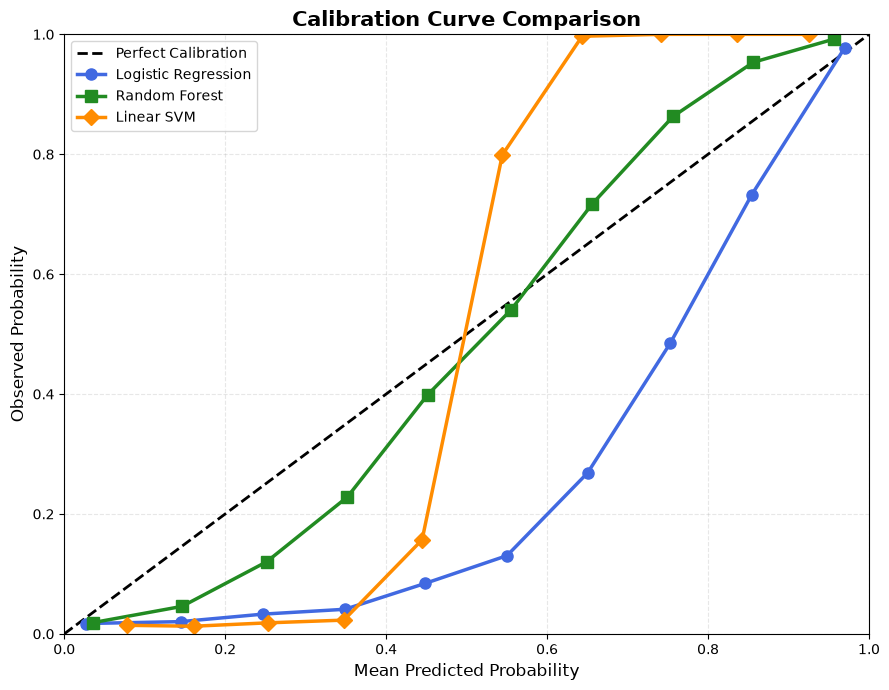

In [16]:
# =============================================================================
# STEP 29 : CALIBRATION CURVE ANALYSIS
# =============================================================================
#
# Objective:
# Compare the calibration performance of Logistic Regression,
# Random Forest, and Linear SVM.
#
# =============================================================================

from sklearn.calibration import calibration_curve
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# =============================================================================
# LOGISTIC REGRESSION
# =============================================================================

log_prob = log_model.predict_proba(
    x_valid_processed
)[:,1]

log_true, log_pred = calibration_curve(
    y_valid,
    log_prob,
    n_bins=10
)

# =============================================================================
# RANDOM FOREST
# =============================================================================

rf_prob = rf_model.predict_proba(
    x_valid_processed
)[:,1]

rf_true, rf_pred = calibration_curve(
    y_valid,
    rf_prob,
    n_bins=10
)

# =============================================================================
# SUPPORT VECTOR MACHINE
# =============================================================================

svm_scores = svm_model.decision_function(
    x_valid_processed
)

svm_prob = MinMaxScaler().fit_transform(
    svm_scores.reshape(-1,1)
).ravel()

svm_true, svm_pred = calibration_curve(
    y_valid,
    svm_prob,
    n_bins=10
)

# =============================================================================
# CALIBRATION CURVE
# =============================================================================

plt.figure(figsize=(9,7))

# Perfect Calibration
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Perfect Calibration"
)

# Logistic Regression
plt.plot(
    log_pred,
    log_true,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="royalblue",
    label="Logistic Regression"
)

# Random Forest
plt.plot(
    rf_pred,
    rf_true,
    marker="s",
    markersize=8,
    linewidth=2.5,
    color="forestgreen",
    label="Random Forest"
)

# Linear SVM
plt.plot(
    svm_pred,
    svm_true,
    marker="D",
    markersize=8,
    linewidth=2.5,
    color="darkorange",
    label="Linear SVM"
)

# =============================================================================
# FORMATTING
# =============================================================================

plt.title(
    "Calibration Curve Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mean Predicted Probability",
    fontsize=12
)

plt.ylabel(
    "Observed Probability",
    fontsize=12
)

plt.xlim(0,1)
plt.ylim(0,1)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend(
    loc="upper left",
    frameon=True
)

plt.tight_layout()

plt.show()

# =============================================================================
# END OF STEP 29 : CALIBRATION CURVE ANALYSIS COMPLETED
# =============================================================================

In [17]:
# =============================================================================
# STEP 30 : OVERALL MODEL PERFORMANCE COMPARISON
# =============================================================================
#
# Objective:
# Summarize and compare the performance of all machine learning
# models using evaluation metrics obtained on the validation set.
#
# =============================================================================

import pandas as pd

comparison_table = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Linear SVM"
    ],

    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        svm_accuracy
    ],

    "Precision": [
        log_precision,
        rf_precision,
        svm_precision
    ],

    "Recall": [
        log_recall,
        rf_recall,
        svm_recall
    ],

    "F1 Score": [
        log_f1,
        rf_f1,
        svm_f1
    ],

    "ROC-AUC": [
        log_roc_auc,
        rf_auc,
        svm_roc_auc
    ],

    "Average Precision": [
        ap_lr,
        ap_rf,
        ap_svm
    ],

    "CV Mean Accuracy": [
        lr_scores.mean(),
        rf_scores.mean(),
        svm_cv.mean()
    ],

    "CV Std Dev": [
        lr_scores.std(),
        rf_scores.std(),
        svm_cv.std()
    ]

})

comparison_table = comparison_table.round(5)

print("=" * 100)
print("OVERALL MODEL PERFORMANCE COMPARISON")
print("=" * 100)

display(comparison_table)

print("-" * 100)

# =============================================================================
# END OF STEP 30 : OVERALL MODEL PERFORMANCE COMPARISON COMPLETED
# =============================================================================

OVERALL MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision,CV Mean Accuracy,CV Std Dev
0,Logistic Regression,0.90532,0.68498,0.90526,0.77986,0.95242,0.91083,0.90630,0.00287
1,Random Forest,0.93885,0.86044,0.79960,0.82890,0.94808,0.89377,0.94113,0.00090
2,Linear SVM,0.90018,0.66992,0.90904,0.77137,0.95226,0.91017,0.94573,0.00119


----------------------------------------------------------------------------------------------------


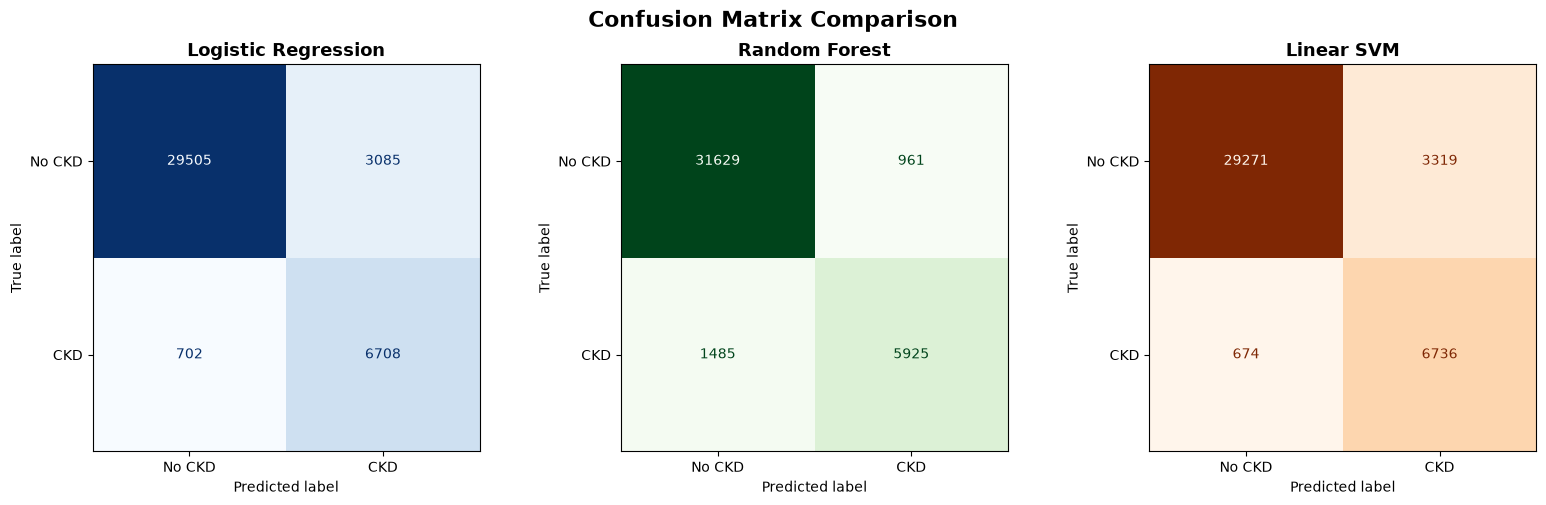

CONFUSION MATRIX COMPARISON COMPLETED SUCCESSFULLY


In [18]:
# =============================================================================
# STEP 31 : CONFUSION MATRIX COMPARISON
# =============================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =============================================================================
# Predictions
# =============================================================================

y_pred_log = log_model.predict(x_valid_processed)
y_pred_rf  = rf_model.predict(x_valid_processed)
y_pred_svm = svm_model.predict(x_valid_processed)

# =============================================================================
# Confusion Matrices
# =============================================================================

cm_log = confusion_matrix(y_valid, y_pred_log)
cm_rf  = confusion_matrix(y_valid, y_pred_rf)
cm_svm = confusion_matrix(y_valid, y_pred_svm)

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16,5)
)

# Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["No CKD", "CKD"]
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

axes[0].set_title(
    "Logistic Regression",
    fontsize=13,
    fontweight="bold"
)

# Random Forest
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No CKD", "CKD"]
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format="d"
)

axes[1].set_title(
    "Random Forest",
    fontsize=13,
    fontweight="bold"
)

# Linear SVM
ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No CKD", "CKD"]
).plot(
    ax=axes[2],
    cmap="Oranges",
    colorbar=False,
    values_format="d"
)

axes[2].set_title(
    "Linear SVM",
    fontsize=13,
    fontweight="bold"
)

fig.suptitle(
    "Confusion Matrix Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# =============================================================================
# OUTPUT
# =============================================================================

print("="*90)
print("CONFUSION MATRIX COMPARISON COMPLETED SUCCESSFULLY")
print("="*90)

# =============================================================================
# END OF STEP 31
# =============================================================================

XGBOOST CLASSIFIER RESULTS
Accuracy  : 0.94840
Precision : 0.89967
Recall    : 0.81201
F1 Score  : 0.85360
ROC-AUC   : 0.95809

Confusion Matrix
[[31919   671]
 [ 1393  6017]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     32590
           1       0.90      0.81      0.85      7410

    accuracy                           0.95     40000
   macro avg       0.93      0.90      0.91     40000
weighted avg       0.95      0.95      0.95     40000

------------------------------------------------------------------------------------------


<Figure size 600x500 with 0 Axes>

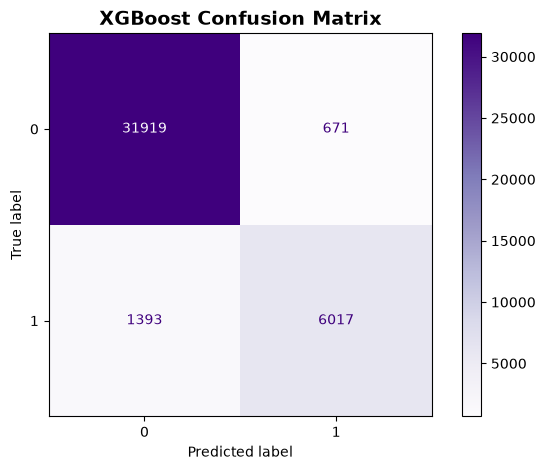

XGBOOST CONFUSION MATRIX
[[31919   671]
 [ 1393  6017]]
------------------------------------------------------------------------------------------


In [19]:
# =============================================================================
# STEP 32 : XGBOOST CLASSIFIER - EARLY CKD SCREENING
# =============================================================================
#
# Objective:
# Train an XGBoost classifier on SMOTE-balanced training data
# and evaluate performance on the validation dataset.
#
# =============================================================================


from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# -----------------------------------------------------------------------------
# Build XGBoost Model
# -----------------------------------------------------------------------------

xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1

)


# -----------------------------------------------------------------------------
# Train Model
# -----------------------------------------------------------------------------

xgb_model.fit(

    x_train_smote,

    y_train_smote

)


# -----------------------------------------------------------------------------
# Prediction
# -----------------------------------------------------------------------------

y_pred_xgb = xgb_model.predict(
    x_valid_processed
)


y_prob_xgb = xgb_model.predict_proba(
    x_valid_processed
)[:,1]


# -----------------------------------------------------------------------------
# Store Metrics
# -----------------------------------------------------------------------------

xgb_accuracy = accuracy_score(
    y_valid,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_valid,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_valid,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_valid,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_valid,
    y_prob_xgb
)



# -----------------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------------

print("="*90)
print("XGBOOST CLASSIFIER RESULTS")
print("="*90)


print(f"Accuracy  : {xgb_accuracy:.5f}")

print(f"Precision : {xgb_precision:.5f}")

print(f"Recall    : {xgb_recall:.5f}")

print(f"F1 Score  : {xgb_f1:.5f}")

print(f"ROC-AUC   : {xgb_auc:.5f}")


print("\nConfusion Matrix")

print(
    confusion_matrix(
        y_valid,
        y_pred_xgb
    )
)


print("\nClassification Report")

print(
    classification_report(
        y_valid,
        y_pred_xgb
    )
)


print("-"*90)


# =============================================================================
# END OF STEP 32
# =============================================================================

# =============================================================================
# STEP 33 : XGBOOST CONFUSION MATRIX VISUALIZATION
# =============================================================================
#
# Objective:
# Visualize the confusion matrix of the XGBoost classifier
# using a coloured heatmap representation.
#
# =============================================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# Plot Confusion Matrix
# -----------------------------------------------------------------------------

plt.figure(figsize=(6,5))


ConfusionMatrixDisplay.from_predictions(

    y_valid,

    y_pred_xgb,

    cmap="Purples",

    colorbar=True

)


plt.title(
    "XGBoost Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()


plt.show()


# -----------------------------------------------------------------------------
# Numerical Confusion Matrix
# -----------------------------------------------------------------------------

print("="*90)
print("XGBOOST CONFUSION MATRIX")
print("="*90)


print(
    confusion_matrix(
        y_valid,
        y_pred_xgb
    )
)


print("-"*90)

# =============================================================================
# END OF STEP 33 : XGBOOST CONFUSION MATRIX COMPLETED
# =============================================================================


Sensitivity Comparison Table
                 Model  Sensitivity (Recall)  Sensitivity (%)
0           Linear SVM              0.909042            90.90
1  Logistic Regression              0.905263            90.53
2        Random Forest              0.799595            79.96

Sensitivity comparison completed successfully.


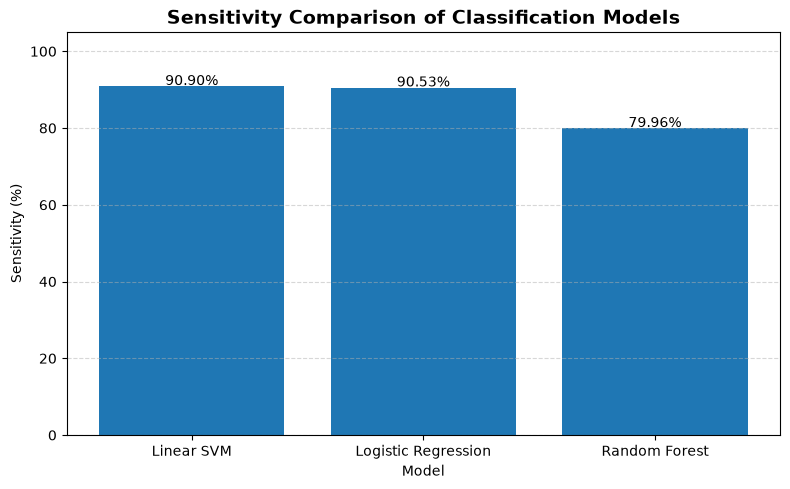


Sensitivity comparison plot generated successfully.


In [20]:
# =============================================================================
# STEP 34 : SENSITIVITY (RECALL) COMPARISON TABLE
# =============================================================================

import pandas as pd
from sklearn.metrics import recall_score

# Calculate Sensitivity (Recall) for each model
sensitivity_lr = recall_score(y_valid, y_pred)
sensitivity_rf = recall_score(y_valid, y_pred_rf)
sensitivity_svm = recall_score(y_valid, y_pred_svm)

# Create comparison table
sensitivity_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Linear SVM"
    ],
    "Sensitivity (Recall)": [
        sensitivity_lr,
        sensitivity_rf,
        sensitivity_svm
    ]
})

# Convert to percentage
sensitivity_table["Sensitivity (%)"] = (
    sensitivity_table["Sensitivity (Recall)"] * 100
).round(2)

# Sort from highest to lowest
sensitivity_table = sensitivity_table.sort_values(
    by="Sensitivity (Recall)",
    ascending=False
).reset_index(drop=True)

print("\nSensitivity Comparison Table")
print("=" * 60)
print(sensitivity_table)

# =============================================================================
# END OF CODE
# =============================================================================

print("\nSensitivity comparison completed successfully.")

# =============================================================================
# SENSITIVITY COMPARISON BAR PLOT
# =============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    sensitivity_table["Model"],
    sensitivity_table["Sensitivity (%)"]
)

plt.title(
    "Sensitivity Comparison of Classification Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Sensitivity (%)")

for i, value in enumerate(sensitivity_table["Sensitivity (%)"]):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =============================================================================
# END OF STEP 34 : SENSITIVITY (RECALL) COMPARISON TABLE COMPLETED
# =============================================================================

print("\nSensitivity comparison plot generated successfully.")


False Negative Rate Comparison
                 Model  False Negative Rate  False Negative Rate (%)
0  Logistic Regression             0.094737                     9.47
1        Random Forest             0.200405                    20.04
2           Linear SVM             0.090958                     9.10


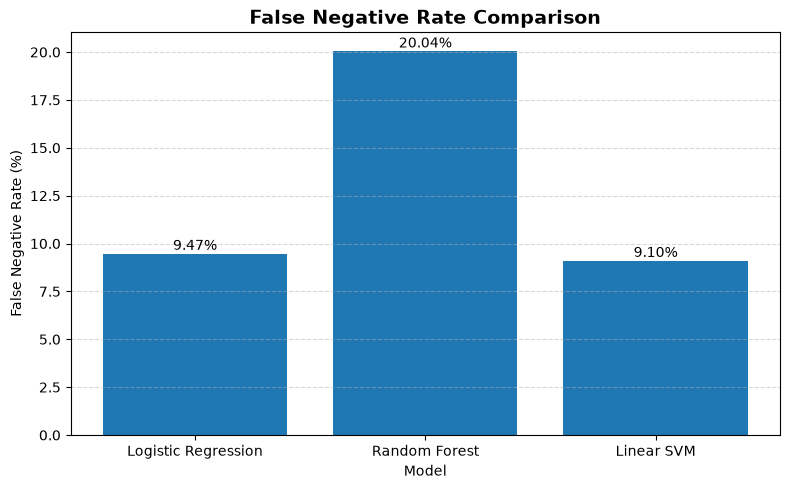


False Negative Rate comparison completed successfully.


In [21]:
# =============================================================================
# STEP 35 : FALSE NEGATIVE RATE (FNR) COMPARISON
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Logistic Regression
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(
    y_valid,
    y_pred
).ravel()

fnr_lr = fn_lr / (fn_lr + tp_lr)


# Random Forest
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(
    y_valid,
    y_pred_rf
).ravel()

fnr_rf = fn_rf / (fn_rf + tp_rf)


# Linear SVM
tn_svm, fp_svm, fn_svm, tp_svm = confusion_matrix(
    y_valid,
    y_pred_svm
).ravel()

fnr_svm = fn_svm / (fn_svm + tp_svm)


# =============================================================================
# CREATE COMPARISON TABLE
# =============================================================================

fnr_table = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Linear SVM"
    ],

    "False Negative Rate": [
        fnr_lr,
        fnr_rf,
        fnr_svm
    ]

})

fnr_table["False Negative Rate (%)"] = (
    fnr_table["False Negative Rate"] * 100
).round(2)

print("\nFalse Negative Rate Comparison")
print("=" * 60)
print(fnr_table)


# =============================================================================
# BAR PLOT
# =============================================================================

plt.figure(figsize=(8,5))

bars = plt.bar(

    fnr_table["Model"],
    fnr_table["False Negative Rate (%)"]

)

plt.title(
    "False Negative Rate Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("False Negative Rate (%)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 0.2,

        f"{height:.2f}%",

        ha="center",

        fontsize=10

    )

plt.tight_layout()
plt.show()


# =============================================================================
# END OF STEP 35 : FALSE NEGATIVE RATE (FNR) COMPARISON COMPLETED
# =============================================================================

print("\nFalse Negative Rate comparison completed successfully.")


False Case Cost Analysis
                 Model  False Positives  False Negatives  Total Cost
0  Logistic Regression             3085              702       10105
1        Random Forest              961             1485       15811
2           Linear SVM             3319              674       10059


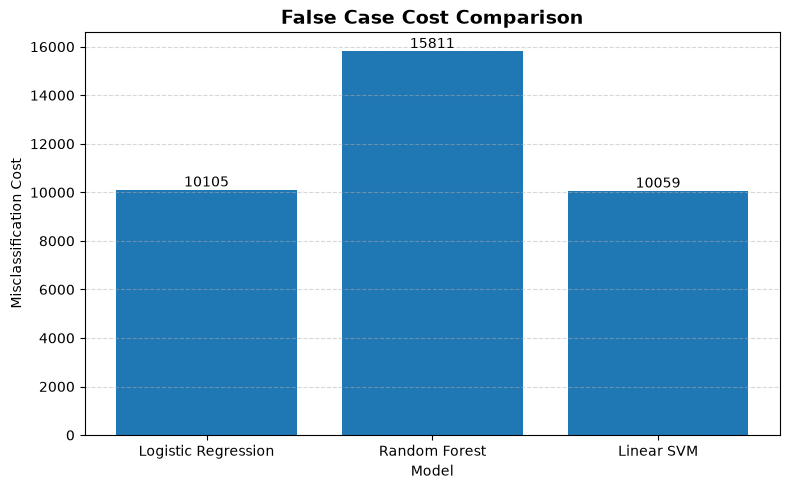


False Case Cost Analysis Completed Successfully.


In [22]:
# =============================================================================
# FALSE CASE COST ANALYSIS
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -------------------------------------------------------------------------
# Define Misclassification Costs
# -------------------------------------------------------------------------

FALSE_POSITIVE_COST = 1      # Unnecessary follow-up screening
FALSE_NEGATIVE_COST = 10     # Missed CKD patient (higher cost)

# -------------------------------------------------------------------------
# Function to Calculate Cost
# -------------------------------------------------------------------------

def calculate_cost(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    total_cost = (
        fp * FALSE_POSITIVE_COST +
        fn * FALSE_NEGATIVE_COST
    )

    return fp, fn, total_cost

# -------------------------------------------------------------------------
# Calculate Cost for Each Model
# -------------------------------------------------------------------------

fp_lr, fn_lr, cost_lr = calculate_cost(
    y_valid,
    y_pred
)

fp_rf, fn_rf, cost_rf = calculate_cost(
    y_valid,
    y_pred_rf
)

fp_svm, fn_svm, cost_svm = calculate_cost(
    y_valid,
    y_pred_svm
)

# -------------------------------------------------------------------------
# Create Cost Comparison Table
# -------------------------------------------------------------------------

cost_table = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Linear SVM"
    ],

    "False Positives":[
        fp_lr,
        fp_rf,
        fp_svm
    ],

    "False Negatives":[
        fn_lr,
        fn_rf,
        fn_svm
    ],

    "Total Cost":[
        cost_lr,
        cost_rf,
        cost_svm
    ]

})

print("\nFalse Case Cost Analysis")
print("="*70)
print(cost_table)

# =============================================================================
# BAR PLOT
# =============================================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    cost_table["Model"],
    cost_table["Total Cost"]
)

plt.title(
    "False Case Cost Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Misclassification Cost")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# =============================================================================
# END OF CODE
# =============================================================================

print("\nFalse Case Cost Analysis Completed Successfully.")

In [23]:
# -------------------------------------------------------------------------
# MACRO AVERAGE METRICS
# -------------------------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score

svm_macro_precision = precision_score(
    y_valid,
    y_pred_svm,
    average="macro"
)

svm_macro_recall = recall_score(
    y_valid,
    y_pred_svm,
    average="macro"
)

svm_macro_f1 = f1_score(
    y_valid,
    y_pred_svm,
    average="macro"
)

# -------------------------------------------------------------------------
# WEIGHTED AVERAGE METRICS
# -------------------------------------------------------------------------

svm_weighted_precision = precision_score(
    y_valid,
    y_pred_svm,
    average="weighted"
)

svm_weighted_recall = recall_score(
    y_valid,
    y_pred_svm,
    average="weighted"
)

svm_weighted_f1 = f1_score(
    y_valid,
    y_pred_svm,
    average="weighted"
)

In [24]:
print("=" * 90)
print("LINEAR SUPPORT VECTOR MACHINE RESULTS")
print("=" * 90)

print(f"Accuracy           : {svm_accuracy:.5f}")
print(f"Precision          : {svm_precision:.5f}")
print(f"Recall             : {svm_recall:.5f}")
print(f"F1 Score           : {svm_f1:.5f}")
print(f"ROC-AUC            : {svm_roc_auc:.5f}")

print("-" * 90)
print("MACRO AVERAGE METRICS")
print("-" * 90)
print(f"Macro Precision    : {svm_macro_precision:.5f}")
print(f"Macro Recall       : {svm_macro_recall:.5f}")
print(f"Macro F1 Score     : {svm_macro_f1:.5f}")

print("-" * 90)
print("WEIGHTED AVERAGE METRICS")
print("-" * 90)
print(f"Weighted Precision : {svm_weighted_precision:.5f}")
print(f"Weighted Recall    : {svm_weighted_recall:.5f}")
print(f"Weighted F1 Score  : {svm_weighted_f1:.5f}")

LINEAR SUPPORT VECTOR MACHINE RESULTS
Accuracy           : 0.90017
Precision          : 0.66992
Recall             : 0.90904
F1 Score           : 0.77137
ROC-AUC            : 0.95226
------------------------------------------------------------------------------------------
MACRO AVERAGE METRICS
------------------------------------------------------------------------------------------
Macro Precision    : 0.82370
Macro Recall       : 0.90360
Macro F1 Score     : 0.85376
------------------------------------------------------------------------------------------
WEIGHTED AVERAGE METRICS
------------------------------------------------------------------------------------------
Weighted Precision : 0.92051
Weighted Recall    : 0.90017
Weighted F1 Score  : 0.90562


Final SVM Pipeline Training Completed

FINAL MODEL PERFORMANCE
--------------------------------
Accuracy: 0.900175
Precision: 0.6699154649428145
Recall: 0.9090418353576248
F1 Score: 0.7713713140566848

Classification Report
--------------------------------
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     32590
           1       0.67      0.91      0.77      7410

    accuracy                           0.90     40000
   macro avg       0.82      0.90      0.85     40000
weighted avg       0.92      0.90      0.91     40000



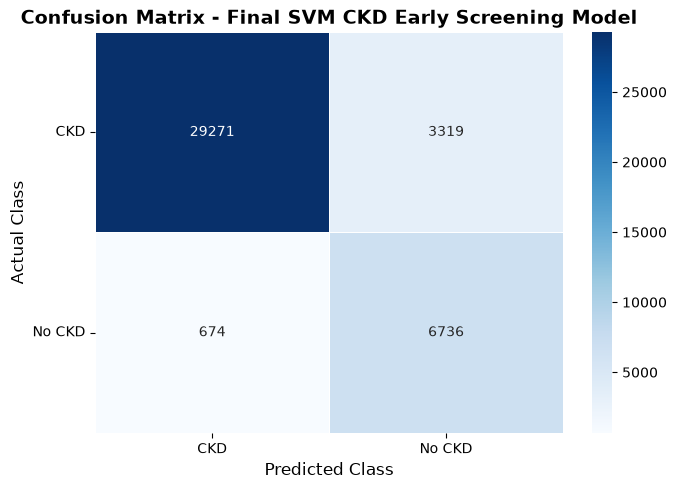


Error Analysis
--------------------------------
TN: 29271
FP: 3319
FN: 674
TP: 6736

Complete SVM Deployment Pipeline Saved


In [25]:
# =============================================================================
# FINAL DEPLOYABLE MODEL : LINEAR SVM CKD EARLY SCREENING
# =============================================================================
#
# Objective:
# Build the final end-to-end CKD screening pipeline including preprocessing
# and Linear SVM classifier.
#
# =============================================================================


import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE



# =============================================================================
# STEP 1 : FINAL PIPELINE CREATION
# =============================================================================

final_svm_pipeline = ImbPipeline([

    ("preprocessor", preprocessor),

    ("smote", SMOTE(
        random_state=42
    )),

    ("classifier", LinearSVC(
        C=1.0,
        random_state=42,
        max_iter=10000
    ))

])



# =============================================================================
# STEP 2 : TRAIN FINAL MODEL
# =============================================================================

final_svm_pipeline.fit(
    x_train,
    y_train
)


print("Final SVM Pipeline Training Completed")



# =============================================================================
# STEP 3 : VALIDATION PREDICTION
# =============================================================================

y_pred_final = final_svm_pipeline.predict(
    x_valid
)



# =============================================================================
# STEP 4 : PERFORMANCE METRICS
# =============================================================================

print("\nFINAL MODEL PERFORMANCE")
print("--------------------------------")

print(
    "Accuracy:",
    accuracy_score(y_valid, y_pred_final)
)

print(
    "Precision:",
    precision_score(y_valid, y_pred_final)
)

print(
    "Recall:",
    recall_score(y_valid, y_pred_final)
)

print(
    "F1 Score:",
    f1_score(y_valid, y_pred_final)
)



print("\nClassification Report")
print("--------------------------------")

print(
    classification_report(
        y_valid,
        y_pred_final
    )
)



# =============================================================================
# STEP 5 : CONFUSION MATRIX
# =============================================================================

# =============================================================================
# CONFUSION MATRIX VISUALIZATION WITH PROPER LABELS
# =============================================================================

cm = confusion_matrix(
    y_valid,
    y_pred_final
)


plt.figure(figsize=(7,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)


plt.title(
    "Confusion Matrix - Final SVM CKD Early Screening Model",
    fontsize=14,
    fontweight="bold"
)


plt.xlabel(
    "Predicted Class",
    fontsize=12
)


plt.ylabel(
    "Actual Class",
    fontsize=12
)


plt.xticks(
    ticks=[0.5, 1.5],
    labels=[
        "CKD",
        "No CKD"
    ]
)


plt.yticks(
    ticks=[0.5, 1.5],
    labels=[
        "CKD",
        "No CKD"
    ],
    rotation=0
)


plt.tight_layout()

plt.show()


# =============================================================================
# STEP 6 : ERROR COUNTS
# =============================================================================

tn, fp, fn, tp = cm.ravel()


print("\nError Analysis")
print("--------------------------------")

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)



# =============================================================================
# STEP 7 : SAVE COMPLETE DEPLOYABLE MODEL
# =============================================================================

joblib.dump(
    final_svm_pipeline,
    "Final_CKD_Early_Screening_SVM_Pipeline.pkl"
)


print("\nComplete SVM Deployment Pipeline Saved")



MARKET SEGMENTATION
Predicted_CKD     High CKD Risk  Low CKD Risk
Health_Insurance                             
Has Insurance              6249         19560
No Insurance               3806         10385


SEGMENT PERCENTAGE
Predicted_CKD     High CKD Risk  Low CKD Risk
Health_Insurance                             
Has Insurance             24.21         75.79
No Insurance              26.82         73.18


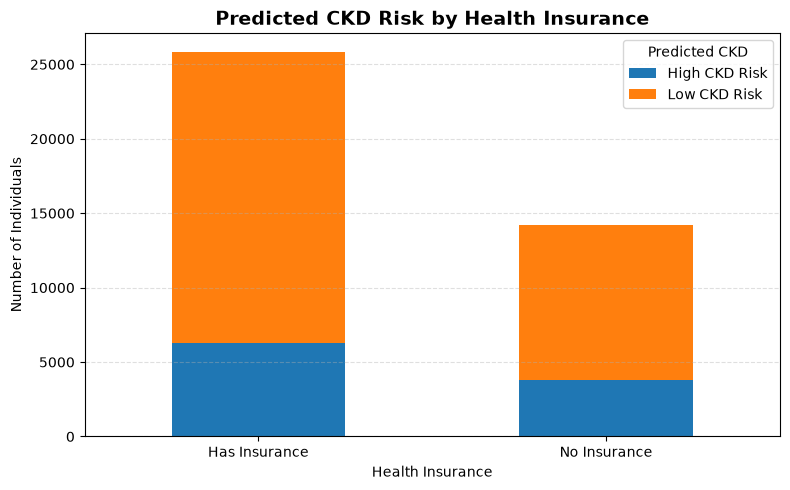



COMMERCIAL INSIGHTS
Total Population                 : 40000
People with Insurance            : 25809
People without Insurance         : 14191
Predicted High CKD Risk          : 10055
High CKD Risk + No Insurance     : 3806

Potential High-Priority Segment (%) : 9.52

Commercial Market Segmentation Completed Successfully.


PORTFOLIO SUMMARY
          Metric  Value  Percentage
0  Total Members  40000      100.00
1       Low Risk  29945       74.86
2      High Risk  10055       25.14
3        Insured  25809       64.52
4      Uninsured  14191       35.48


RISK DISTRIBUTION
  Risk Level  Members
0   Low Risk    29945
1  High Risk    10055


INSURANCE PORTFOLIO
Risk_Level        High Risk  Low Risk
Health_Insurance                     
Has Insurance          6249     19560
No Insurance           3806     10385


RISK PERCENTAGE
Risk_Level        High Risk  Low Risk
Health_Insurance                     
Has Insurance         24.21     75.79
No Insurance          26.82     73.18


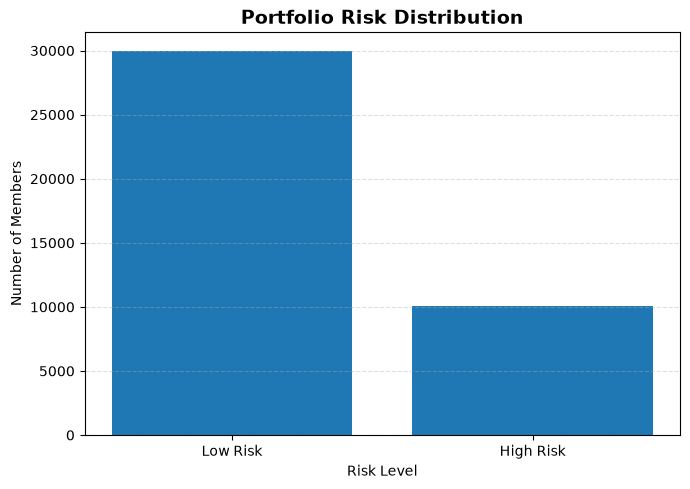

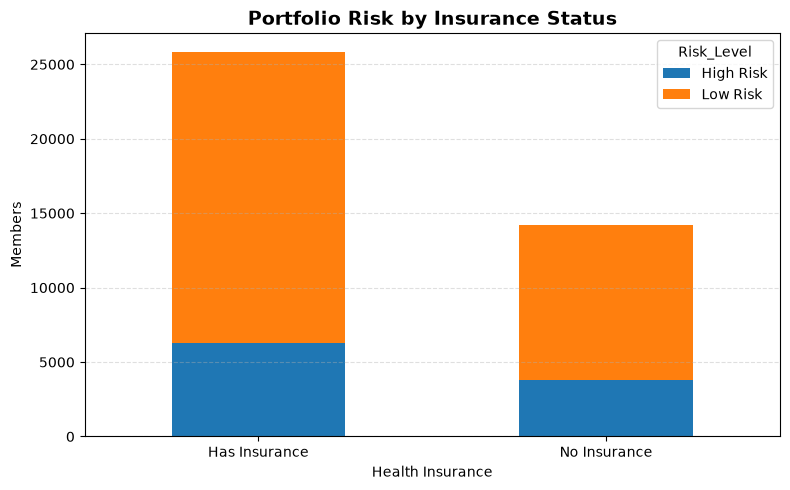



HIGH-RISK PORTFOLIO PROFILE
                 Age     Sex Ethnicity Country Residence_Type Education_Level  \
count   10055.000000   10055     10055   10055          10055           10055   
unique           NaN       2         5       6              2               5   
top              NaN  Female     White     USA          Urban     High School   
freq             NaN    5855      5492    4601           6201            3217   
mean       64.528692     NaN       NaN     NaN            NaN             NaN   
std        12.688442     NaN       NaN     NaN            NaN             NaN   
min        18.000000     NaN       NaN     NaN            NaN             NaN   
25%        56.000000     NaN       NaN     NaN            NaN             NaN   
50%        64.000000     NaN       NaN     NaN            NaN             NaN   
75%        73.000000     NaN       NaN     NaN            NaN             NaN   
max        95.000000     NaN       NaN     NaN            NaN             NaN  

In [26]:
# =============================================================================
# COMMERCIAL INSIGHT:
# MARKET SEGMENTATION USING HEALTH INSURANCE + SVM PREDICTIONS
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# CREATE ANALYSIS DATAFRAME
# -------------------------------------------------------------------------

commercial_df = x_valid.copy()

commercial_df["Predicted_CKD"] = y_pred_svm

commercial_df["Health_Insurance"] = commercial_df[
    "Health_Insurance"
].replace({

    0: "No Insurance",
    1: "Has Insurance"

})

commercial_df["Predicted_CKD"] = commercial_df[
    "Predicted_CKD"
].replace({

    0: "Low CKD Risk",
    1: "High CKD Risk"

})

# -------------------------------------------------------------------------
# MARKET SEGMENTATION
# -------------------------------------------------------------------------

segment_table = pd.crosstab(

    commercial_df["Health_Insurance"],

    commercial_df["Predicted_CKD"]

)

print("\n")
print("="*70)
print("MARKET SEGMENTATION")
print("="*70)

print(segment_table)

# -------------------------------------------------------------------------
# PERCENTAGE
# -------------------------------------------------------------------------

segment_percent = (

    pd.crosstab(

        commercial_df["Health_Insurance"],

        commercial_df["Predicted_CKD"],

        normalize="index"

    ) * 100

).round(2)

print("\n")
print("="*70)
print("SEGMENT PERCENTAGE")
print("="*70)

print(segment_percent)

# -------------------------------------------------------------------------
# STACKED BAR CHART
# -------------------------------------------------------------------------

segment_table.plot(

    kind="bar",

    stacked=True,

    figsize=(8,5)

)

plt.title(
    "Predicted CKD Risk by Health Insurance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health Insurance")

plt.ylabel("Number of Individuals")

plt.xticks(rotation=0)

plt.legend(title="Predicted CKD")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# -------------------------------------------------------------------------
# COMMERCIAL SUMMARY
# -------------------------------------------------------------------------

total_population = len(commercial_df)

insured = (
    commercial_df["Health_Insurance"] == "Has Insurance"
).sum()

uninsured = (
    commercial_df["Health_Insurance"] == "No Insurance"
).sum()

high_risk = (
    commercial_df["Predicted_CKD"] == "High CKD Risk"
).sum()

high_risk_uninsured = len(

commercial_df[

    (commercial_df["Health_Insurance"]=="No Insurance") &

    (commercial_df["Predicted_CKD"]=="High CKD Risk")

]

)

print("\n")
print("="*70)
print("COMMERCIAL INSIGHTS")
print("="*70)

print(f"Total Population                 : {total_population}")
print(f"People with Insurance            : {insured}")
print(f"People without Insurance         : {uninsured}")
print(f"Predicted High CKD Risk          : {high_risk}")
print(f"High CKD Risk + No Insurance     : {high_risk_uninsured}")

print("\nPotential High-Priority Segment (%) :",
      round(high_risk_uninsured/total_population*100,2))

# =============================================================================
# END OF CODE
# =============================================================================

print("\nCommercial Market Segmentation Completed Successfully.")

# =============================================================================
# PORTFOLIO LEVEL RISK REPORT
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# CREATE PORTFOLIO DATA
# -----------------------------------------------------------------------------

portfolio = x_valid.copy()

portfolio["Predicted_CKD"] = y_pred_svm

portfolio["Health_Insurance"] = portfolio["Health_Insurance"].replace({
    0: "No Insurance",
    1: "Has Insurance"
})

portfolio["Risk_Level"] = portfolio["Predicted_CKD"].replace({
    0: "Low Risk",
    1: "High Risk"
})

# -----------------------------------------------------------------------------
# OVERALL PORTFOLIO SUMMARY
# -----------------------------------------------------------------------------

total_members = len(portfolio)

high_risk = (portfolio["Risk_Level"] == "High Risk").sum()
low_risk = (portfolio["Risk_Level"] == "Low Risk").sum()

insured = (portfolio["Health_Insurance"] == "Has Insurance").sum()
uninsured = (portfolio["Health_Insurance"] == "No Insurance").sum()

summary = pd.DataFrame({

    "Metric":[
        "Total Members",
        "Low Risk",
        "High Risk",
        "Insured",
        "Uninsured"
    ],

    "Value":[
        total_members,
        low_risk,
        high_risk,
        insured,
        uninsured
    ]

})

summary["Percentage"] = (
    summary["Value"] / total_members * 100
).round(2)

print("\n")
print("="*70)
print("PORTFOLIO SUMMARY")
print("="*70)

print(summary)

# -----------------------------------------------------------------------------
# RISK DISTRIBUTION
# -----------------------------------------------------------------------------

risk_distribution = (
    portfolio["Risk_Level"]
    .value_counts()
    .reset_index()
)

risk_distribution.columns = ["Risk Level", "Members"]

print("\n")
print("="*70)
print("RISK DISTRIBUTION")
print("="*70)

print(risk_distribution)

# -----------------------------------------------------------------------------
# RISK VS INSURANCE
# -----------------------------------------------------------------------------

insurance_risk = pd.crosstab(

    portfolio["Health_Insurance"],

    portfolio["Risk_Level"]

)

print("\n")
print("="*70)
print("INSURANCE PORTFOLIO")
print("="*70)

print(insurance_risk)

# -----------------------------------------------------------------------------
# HIGH RISK PERCENTAGE
# -----------------------------------------------------------------------------

portfolio_percentage = (

    insurance_risk.div(
        insurance_risk.sum(axis=1),
        axis=0
    ) * 100

).round(2)

print("\n")
print("="*70)
print("RISK PERCENTAGE")
print("="*70)

print(portfolio_percentage)

# -----------------------------------------------------------------------------
# BAR CHART
# -----------------------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.bar(

    risk_distribution["Risk Level"],

    risk_distribution["Members"]

)

plt.title(
    "Portfolio Risk Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Risk Level")

plt.ylabel("Number of Members")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# -----------------------------------------------------------------------------
# STACKED BAR CHART
# -----------------------------------------------------------------------------

insurance_risk.plot(

    kind="bar",

    stacked=True,

    figsize=(8,5)

)

plt.title(
    "Portfolio Risk by Insurance Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Health Insurance")

plt.ylabel("Members")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# -----------------------------------------------------------------------------
# TOP 10 HIGH-RISK PORTFOLIO SUMMARY
# -----------------------------------------------------------------------------

high_risk_members = portfolio[
    portfolio["Risk_Level"] == "High Risk"
]

print("\n")
print("="*70)
print("HIGH-RISK PORTFOLIO PROFILE")
print("="*70)

print(high_risk_members.describe(include="all"))

# =============================================================================
# END OF CODE
# =============================================================================

print("\nPortfolio-Level Risk Report Generated Successfully.")

In [27]:
# =============================================================================
# STEP 11 : EXECUTIVE INSURANCE PORTFOLIO SUNBURST
# =============================================================================

import plotly.express as px

# ---------------------------------------------------------------------
# Create dashboard dataframe
# ---------------------------------------------------------------------

dashboard = portfolio.copy()

# Remove missing values
dashboard = dashboard.dropna(
    subset=[
        "Country",
        "Health_Insurance",
        "Predicted_CKD",
        "Risk_Level",
        "Socioeconomic_Status"
    ]
)

# Convert categorical columns to string
dashboard["Risk_Level"] = dashboard["Risk_Level"].astype(str)
dashboard["Predicted_CKD"] = dashboard["Predicted_CKD"].astype(str)
dashboard["Health_Insurance"] = dashboard["Health_Insurance"].astype(str)

# ---------------------------------------------------------------------
# Executive Sunburst
# ---------------------------------------------------------------------

fig = px.sunburst(

    dashboard,

    path=[

        "Country",
        "Health_Insurance",
        "Predicted_CKD",
        "Risk_Level",
        "Socioeconomic_Status"

    ],

    color="Risk_Level",

    color_discrete_map={

        "Low": "#2ECC71",         # Green
        "Moderate": "#F1C40F",    # Yellow
        "High": "#E67E22",        # Orange
        "Very High": "#E74C3C"    # Red

    },

    hover_data={

        "Age": True,
        "BMI": ":.1f",
        "Annual_Household_Income_USD": ":,.0f"

    },

    maxdepth=5,

    title="<b>Executive Insurance Portfolio Analysis</b>"

)

# ---------------------------------------------------------------------
# Improve appearance
# ---------------------------------------------------------------------

fig.update_traces(

    textinfo="label+percent parent",

    insidetextorientation="radial",

    hovertemplate=
    "<b>%{label}</b><br>"
    "Members: %{value}<br>"
    "Parent: %{percentParent:.1%}<br>"
    "Root: %{percentRoot:.1%}<extra></extra>"

)

fig.update_layout(

    template="plotly_white",

    width=1300,

    height=850,

    margin=dict(

        l=20,
        r=20,
        t=70,
        b=20

    ),

    font=dict(

        family="Arial",
        size=15

    ),

    title_x=0.5

)

fig.show()

print("\nExecutive Sunburst generated successfully.")

# =============================================================================
# STEP 9 : INSURANCE PORTFOLIO RISK LANDSCAPE
# =============================================================================

import plotly.express as px

# -------------------------------------------------------------------------
# Create Risk Group
# -------------------------------------------------------------------------

portfolio = portfolio.copy()

portfolio["Risk_Group"] = (
    portfolio["Predicted_CKD"].astype(str)
    + " | "
    + portfolio["Health_Insurance"].astype(str)
)

# -------------------------------------------------------------------------
# Interactive Bubble Chart
# -------------------------------------------------------------------------

fig = px.scatter(

    portfolio,

    x="Annual_Household_Income_USD",

    y="Age",

    size="BMI",

    color="Risk_Group",

    symbol="Health_Insurance",

    hover_name="Country",

    hover_data={

        "Lifestyle_Risk": True,

        "Metabolic_Risk": True,

        "CV_Risk": True,

        "Risk_Level": True,

        "BMI": ":.1f",

        "Annual_Household_Income_USD": ":,.0f",

        "Age": True

    },

    color_discrete_map={

        "Low CKD Risk | Has Insurance": "#1ABC9C",

        "Low CKD Risk | No Insurance": "#3498DB",

        "High CKD Risk | Has Insurance": "#F39C12",

        "High CKD Risk | No Insurance": "#E74C3C"

    },

    title="<b>Insurance Portfolio Risk Landscape</b>"

)

# -------------------------------------------------------------------------
# Improve Marker Appearance
# -------------------------------------------------------------------------

fig.update_traces(

    marker=dict(

        opacity=0.75,

        line=dict(

            color="black",

            width=0.5

        )

    )

)

# -------------------------------------------------------------------------
# Improve Layout
# -------------------------------------------------------------------------

fig.update_layout(

    template="plotly_white",

    width=1250,

    height=720,

    title_x=0.5,

    font=dict(

        family="Arial",

        size=14

    ),

    legend_title="Portfolio Segment",

    xaxis=dict(

        title="Annual Household Income (USD)",

        showgrid=True,

        zeroline=False

    ),

    yaxis=dict(

        title="Age (Years)",

        showgrid=True,

        zeroline=False

    )

)

fig.show()

print("\nInsurance Portfolio Risk Landscape generated successfully.")


Executive Sunburst generated successfully.



Insurance Portfolio Risk Landscape generated successfully.


In [28]:
# =============================================================================
# SAVE FINAL MODEL
# =============================================================================

import joblib

MODEL_PATH = "D:\\project\\data\\raw\\CKD_API\\Final_CKD_Early_Screening_SVM_Pipeline.pkl"

joblib.dump(final_svm_pipeline, MODEL_PATH)

print("="*70)
print("MODEL SAVED SUCCESSFULLY")
print("="*70)
print(f"Location : {MODEL_PATH}")

import joblib

model = joblib.load("D:\\project\\data\\raw\\CKD_API\\Final_CKD_Early_Screening_SVM_Pipeline.pkl")

print(type(model))
# =============================================================================
# FINAL MODEL PERFORMANCE SUMMARY
# =============================================================================

final_results = pd.DataFrame({

    "Model": [
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_valid, y_pred_final)
    ],

    "Precision": [
        precision_score(y_valid, y_pred_final)
    ],

    "Recall": [
        recall_score(y_valid, y_pred_final)
    ],

    "F1_Score": [
        f1_score(y_valid, y_pred_final)
    ],

    "False_Negative": [
        fn
    ],

    "False_Positive": [
        fp
    ]

})


final_results


MODEL SAVED SUCCESSFULLY
Location : D:\project\data\raw\CKD_API\Final_CKD_Early_Screening_SVM_Pipeline.pkl
<class 'imblearn.pipeline.Pipeline'>


,Model,Accuracy,Precision,Recall,F1_Score,False_Negative,False_Positive
0,Linear SVM,0.900175,0.669915,0.909042,0.771371,674,3319


In [29]:
import joblib

final_svm_pipeline = joblib.load("Final_CKD_Early_Screening_SVM_Pipeline.pkl")

print(final_svm_pipeline.feature_names_in_)

import joblib

model = joblib.load("Final_CKD_Early_Screening_SVM_Pipeline.pkl")

print(model)

from sklearn.pipeline import Pipeline
import joblib

deployment_pipeline = Pipeline(
    steps=[
        ("preprocessor", final_svm_pipeline.named_steps["preprocessor"]),
        ("classifier", final_svm_pipeline.named_steps["classifier"])
    ]
)

joblib.dump(
    deployment_pipeline,
    "CKD_API_Model.pkl"
)

print("Deployment model saved successfully.")

['Age' 'Sex' 'Ethnicity' 'Country' 'Residence_Type' 'Education_Level'
 'Socioeconomic_Status' 'Height_cm' 'Weight_kg' 'BMI'
 'Waist_Circumference_cm' 'Body_Fat_Percentage' 'Smoking_Status'
 'Alcohol_Consumption' 'Physical_Activity_Level' 'Exercise_Hours_Per_Week'
 'Daily_Steps' 'Water_Intake_L' 'Sodium_Intake_mg'
 'Fast_Food_Frequency_Per_Week' 'Sleep_Duration_Hours' 'Stress_Level'
 'Diabetes' 'Hypertension' 'Cardiovascular_Disease' 'Heart_Failure'
 'Hyperlipidemia' 'Kidney_Stones' 'Recurrent_UTI' 'Autoimmune_Disease'
 'Family_History_CKD' 'Obesity' 'Heart_Rate' 'Respiratory_Rate'
 'Oxygen_Saturation' 'Systolic_BP' 'Diastolic_BP'
 'Blood_Pressure_Category' 'NSAID_Usage' 'Annual_Checkups'
 'Health_Insurance' 'Annual_Household_Income_USD' 'Employment_Status'
 'Pulse_Pressure' 'Waist_to_Height' 'Lifestyle_Risk' 'Metabolic_Risk'
 'CV_Risk' 'Poor_Sleep']
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                

In [30]:
# =============================================================================
# CLINICAL ERROR RATES
# =============================================================================

type_I_error_rate = fn / (fn + tp)

type_II_error_rate = fp / (fp + tn)


print("Type I Error Rate (Missed CKD):",
      type_I_error_rate)


print("Type II Error Rate (False Alarm):",
      type_II_error_rate)

# =============================================================================
# FALSE NEGATIVE PATIENT ANALYSIS
# =============================================================================

false_negative = (
    (y_valid == 1) &
    (y_pred_final == 0)
)


FN_data = x_valid.loc[
    false_negative
]


print(
    "False Negative Patients:",
    FN_data.shape[0]
)


FN_data.head()

# =============================================================================
# FALSE POSITIVE PATIENT ANALYSIS
# =============================================================================

false_positive = (
    (y_valid == 0) &
    (y_pred_final == 1)
)


FP_data = x_valid.loc[
    false_positive
]


print(
    "False Positive Patients:",
    FP_data.shape[0]
)


FP_data.head()

Type I Error Rate (Missed CKD): 0.09095816464237517
Type II Error Rate (False Alarm): 0.10184105553850875
False Negative Patients: 674
False Positive Patients: 3319


,Age,Sex,Ethnicity,Country,Residence_Type,Education_Level,Socioeconomic_Status,Height_cm,Weight_kg,BMI,...,Annual_Checkups,Health_Insurance,Annual_Household_Income_USD,Employment_Status,Pulse_Pressure,Waist_to_Height,Lifestyle_Risk,Metabolic_Risk,CV_Risk,Poor_Sleep
112981,50,Female,Black,Australia,Urban,Some College,Middle,164.4,100.8,37.3,...,1,1,67700,Employed,53,NaN,0,2,0,1
134972,67,Male,Hispanic,USA,Urban,Bachelor's,High,170.6,88.5,30.4,...,1,1,191100,Employed,52,0.579719,0,2,1,0
188647,80,Female,White,USA,Urban,High School,High,161.7,83.9,32.1,...,3,1,158400,Employed,59,0.573284,0,1,1,0
8702,48,Male,White,USA,Rural,High School,High,170.9,58.7,20.1,...,3,1,162500,Employed,58,0.416618,1,1,1,0
85800,52,Male,Black,Australia,Rural,Some College,Low,173.7,70.6,23.4,...,3,1,17300,Unemployed/Retired,42,0.455383,0,1,0,0


In [31]:
# =============================================================================
# CHECK SAVED PIPELINE STATUS
# =============================================================================

import joblib
from sklearn.utils.validation import check_is_fitted


loaded_svm_model = joblib.load("CKD_API_Model.pkl")


print(loaded_svm_model)


try:
    check_is_fitted(loaded_svm_model)
    print("\nMODEL STATUS : FITTED")

except:
    print("\nMODEL STATUS : NOT FITTED")

    # =============================================================================
# FINAL SVM TRAINING
# =============================================================================


svm_pipeline.fit(
    x_train,
    y_train
)


print("SVM MODEL TRAINED SUCCESSFULLY")

# =============================================================================
# SAVE FINAL DEPLOYMENT PIPELINE
# =============================================================================


joblib.dump(
    svm_pipeline,
    "CKD_API_Model.pkl"
)


print("FINAL CKD SVM PIPELINE SAVED SUCCESSFULLY")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height_cm',
                                                   'Weight_kg', 'BMI',
                                                   'Waist_Circumference_cm',
                                                   'Body_Fat_Percentage',
                                                   'Exercise_Hours_Per_Week',
                                                   'Daily_Steps',
                                                   'Water_Intake_L',
                                                   'Sodium_

In [32]:
# =============================================================================
# STEP 8 : DEPLOYMENT TESTING OF FINAL CKD SVM MODEL
# =============================================================================
#
# Objective:
# Verify that the saved CKD SVM pipeline can be loaded successfully
# and generate predictions on unseen validation data.
#
# =============================================================================

import joblib
import pandas as pd

# =============================================================================
# LOAD SAVED DEPLOYMENT MODEL
# =============================================================================


loaded_svm_model = joblib.load("CKD_API_Model.pkl")

print("=" * 70)
print("FINAL CKD SVM PIPELINE LOADED SUCCESSFULLY")
print("=" * 70)

# =============================================================================
# GENERATE PREDICTIONS
# =============================================================================

deployment_predictions = loaded_svm_model.predict(x_valid)

# =============================================================================
# DISPLAY PREDICTION RESULTS
# =============================================================================

print("\nFirst 20 Predictions")
print("-" * 40)
print(deployment_predictions[:20])

print("\nPrediction Distribution")
print("-" * 40)
print(pd.Series(deployment_predictions).value_counts())

print("\nDeployment Testing Completed Successfully.")

# =============================================================================
# STEP 9 : SVM DECISION SCORE GENERATION
# =============================================================================
#
# Objective:
# Generate decision scores from the deployed SVM model to estimate
# the confidence of CKD risk predictions.
#
# =============================================================================

svm_scores = loaded_svm_model.decision_function(x_valid)

# =============================================================================
# DISPLAY DECISION SCORES
# =============================================================================

print("\nFirst 20 Decision Scores")
print("-" * 40)
print(svm_scores[:20])

print("\nDecision Score Summary")
print("-" * 40)
print(pd.Series(svm_scores).describe())

print("\nDecision Score Generation Completed Successfully.")

FINAL CKD SVM PIPELINE LOADED SUCCESSFULLY

First 20 Predictions
----------------------------------------
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0]

Prediction Distribution
----------------------------------------
0    29945
1    10055
Name: count, dtype: int64

Deployment Testing Completed Successfully.

First 20 Decision Scores
----------------------------------------
[-0.6197979  -1.13076364 -1.58125289 -0.67970678 -0.91581035  0.1224554
 -1.21652685 -0.31073801 -2.24729271 -0.29911272 -0.13334572 -0.4147191
 -1.33409835 -0.86267888  0.2315666  -0.30042736 -1.03832332  0.66463817
 -1.19828949 -1.11595653]

Decision Score Summary
----------------------------------------
count    40000.000000
mean        -0.560539
std          0.982786
min         -2.868855
25%         -1.267723
50%         -0.708008
75%          0.004637
max          3.658426
dtype: float64

Decision Score Generation Completed Successfully.


In [33]:
from sklearn.utils.validation import check_is_fitted


try:
    check_is_fitted(svm_pipeline)
    print("SVM PIPELINE IS FITTED")

except:
    print("SVM PIPELINE IS NOT FITTED")

# =============================================================================
# FINAL CKD SVM PIPELINE TRAINING
# =============================================================================


svm_pipeline.fit(
    x_train,
    y_train
)


print("="*70)
print("FINAL CKD SVM PIPELINE TRAINED SUCCESSFULLY")
print("="*70)

from sklearn.metrics import accuracy_score, classification_report


y_pred = svm_pipeline.predict(x_valid)


print("Validation Accuracy:")
print(
    accuracy_score(
        y_valid,
        y_pred
    )
)


print("\nClassification Report")
print(
    classification_report(
        y_valid,
        y_pred
    )
)

import joblib


joblib.dump(
    svm_pipeline,
    "CKD_API_Model.pkl"
)


print("FITTED CKD SVM PIPELINE SAVED SUCCESSFULLY")

loaded_svm_model = joblib.load(
    "CKD_API_Model.pkl"
)


deployment_predictions = loaded_svm_model.predict(
    x_valid
)


print(deployment_predictions[:20])

SVM PIPELINE IS FITTED
FINAL CKD SVM PIPELINE TRAINED SUCCESSFULLY
Validation Accuracy:
0.900175

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     32590
           1       0.67      0.91      0.77      7410

    accuracy                           0.90     40000
   macro avg       0.82      0.90      0.85     40000
weighted avg       0.92      0.90      0.91     40000

FITTED CKD SVM PIPELINE SAVED SUCCESSFULLY
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0]


In [34]:
# =============================================================================
# DEPLOYMENT LOAD TEST
# =============================================================================


import joblib


loaded_svm_model = joblib.load(
    "CKD_API_Model.pkl"
)


print(type(loaded_svm_model))


print(
    "MODEL LOADED SUCCESSFULLY"
)

# =============================================================================
# DEPLOYMENT PREDICTION TEST
# =============================================================================


deployment_predictions = loaded_svm_model.predict(
    x_valid
)


print("="*70)
print("FIRST 20 DEPLOYMENT PREDICTIONS")
print("="*70)


print(
    deployment_predictions[:20]
)


print("\nPrediction Distribution")


import pandas as pd


print(
    pd.Series(
        deployment_predictions
    ).value_counts()
)

# =============================================================================
# SVM CONFIDENCE SCORE TEST
# =============================================================================


svm_scores = loaded_svm_model.decision_function(
    x_valid
)


print("="*70)
print("FIRST 20 SVM DECISION SCORES")
print("="*70)


print(
    svm_scores[:20]
)


print("\nSUMMARY")

print(
    pd.Series(
        svm_scores
    ).describe()
)

# =============================================================================
# STEP 9 : SVM DECISION SCORE GENERATION
# =============================================================================
#
# Objective:
# Generate decision scores from the deployed CKD SVM model.
# Decision scores indicate the confidence of the classifier:
#
#   Score > 0  → Predicted CKD Risk (Class 1)
#   Score < 0  → Predicted Low CKD Risk (Class 0)
#
# Larger absolute values indicate higher confidence.
#
# =============================================================================

import pandas as pd
import numpy as np

# =============================================================================
# GENERATE DECISION SCORES
# =============================================================================

svm_scores = loaded_svm_model.decision_function(x_valid)

# =============================================================================
# DISPLAY FIRST 20 DECISION SCORES
# =============================================================================

print("=" * 70)
print("SVM DECISION SCORE GENERATION")
print("=" * 70)

print("\nFIRST 20 DECISION SCORES")
print("-" * 40)

print(svm_scores[:20])

# =============================================================================
# DECISION SCORE SUMMARY
# =============================================================================

print("\nDECISION SCORE SUMMARY")
print("-" * 40)

decision_summary = pd.Series(svm_scores).describe()

print(decision_summary)

# =============================================================================
# CONFIDENCE ANALYSIS
# =============================================================================

print("\nCONFIDENCE ANALYSIS")
print("-" * 40)

positive_scores = np.sum(svm_scores > 0)
negative_scores = np.sum(svm_scores < 0)
zero_scores = np.sum(svm_scores == 0)

print(f"Positive Scores (>0) : {positive_scores}")
print(f"Negative Scores (<0) : {negative_scores}")
print(f"Exactly Zero Scores  : {zero_scores}")

# =============================================================================
# EXTREME CONFIDENCE VALUES
# =============================================================================

print("\nEXTREME DECISION SCORES")
print("-" * 40)

print(f"Highest Score : {svm_scores.max():.6f}")
print(f"Lowest Score  : {svm_scores.min():.6f}")

# =============================================================================
# DEPLOYMENT VERIFICATION
# =============================================================================

print("\nDEPLOYMENT DECISION SCORE VERIFICATION")
print("-" * 40)

print(f"Decision Scores Generated : {len(svm_scores)}")
print(f"Validation Samples        : {len(x_valid)}")

if len(svm_scores) == len(x_valid):
    print("Decision Score Check      : PASSED")
else:
    print("Decision Score Check      : FAILED")

print("\nDecision score generation completed successfully.")

# =============================================================================
# END OF STEP 9
# =============================================================================

<class 'imblearn.pipeline.Pipeline'>
MODEL LOADED SUCCESSFULLY
FIRST 20 DEPLOYMENT PREDICTIONS
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0]

Prediction Distribution
0    29945
1    10055
Name: count, dtype: int64
FIRST 20 SVM DECISION SCORES
[-0.6197979  -1.13076364 -1.58125289 -0.67970678 -0.91581035  0.1224554
 -1.21652685 -0.31073801 -2.24729271 -0.29911272 -0.13334572 -0.4147191
 -1.33409835 -0.86267888  0.2315666  -0.30042736 -1.03832332  0.66463817
 -1.19828949 -1.11595653]

SUMMARY
count    40000.000000
mean        -0.560539
std          0.982786
min         -2.868855
25%         -1.267723
50%         -0.708008
75%          0.004637
max          3.658426
dtype: float64
SVM DECISION SCORE GENERATION

FIRST 20 DECISION SCORES
----------------------------------------
[-0.6197979  -1.13076364 -1.58125289 -0.67970678 -0.91581035  0.1224554
 -1.21652685 -0.31073801 -2.24729271 -0.29911272 -0.13334572 -0.4147191
 -1.33409835 -0.86267888  0.2315666  -0.30042736 -1.03832332  0.66463817
 -1.

In [35]:
# =============================================================================
# STEP 10 : FINAL DEPLOYMENT MODEL PERFORMANCE REPORT
# =============================================================================
#
# Objective:
# Evaluate the predictive performance of the deployed CKD SVM pipeline
# using the unseen validation dataset.
#
# =============================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

# =============================================================================
# GENERATE DEPLOYMENT PREDICTIONS
# =============================================================================

deployment_predictions = loaded_svm_model.predict(x_valid)
deployment_scores = loaded_svm_model.decision_function(x_valid)

# =============================================================================
# COMPUTE PERFORMANCE METRICS
# =============================================================================

deployment_accuracy = accuracy_score(y_valid, deployment_predictions)
deployment_precision = precision_score(y_valid, deployment_predictions)
deployment_recall = recall_score(y_valid, deployment_predictions)
deployment_f1 = f1_score(y_valid, deployment_predictions)
deployment_auc = roc_auc_score(y_valid, deployment_scores)

# =============================================================================
# DISPLAY PERFORMANCE METRICS
# =============================================================================

print("=" * 70)
print("FINAL DEPLOYMENT MODEL PERFORMANCE REPORT")
print("=" * 70)

print(f"\nAccuracy      : {deployment_accuracy:.6f}")
print(f"Precision     : {deployment_precision:.6f}")
print(f"Recall        : {deployment_recall:.6f}")
print(f"F1 Score      : {deployment_f1:.6f}")
print(f"ROC-AUC Score : {deployment_auc:.6f}")

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

deployment_cm = confusion_matrix(
    y_valid,
    deployment_predictions
)

print("\n")
print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

cm_df = pd.DataFrame(
    deployment_cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

print(cm_df)

# =============================================================================
# CLASSIFICATION REPORT
# =============================================================================

print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_valid,
        deployment_predictions,
        digits=4
    )
)

# =============================================================================
# ERROR ANALYSIS
# =============================================================================

TN, FP, FN, TP = deployment_cm.ravel()

print("\n")
print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print(f"True Positives  : {TP}")
print(f"True Negatives  : {TN}")
print(f"False Positives : {FP}")
print(f"False Negatives : {FN}")

# =============================================================================
# DEPLOYMENT SUMMARY
# =============================================================================

correct = (deployment_predictions == y_valid).sum()
incorrect = len(y_valid) - correct

print("\n")
print("=" * 70)
print("DEPLOYMENT SUMMARY")
print("=" * 70)

print(f"Validation Samples : {len(y_valid)}")
print(f"Correct Predictions: {correct}")
print(f"Incorrect Predictions: {incorrect}")

print("\nDeployment model performance verified successfully.")

# =============================================================================
# END OF STEP 10
# =============================================================================

FINAL DEPLOYMENT MODEL PERFORMANCE REPORT

Accuracy      : 0.900175
Precision     : 0.669915
Recall        : 0.909042
F1 Score      : 0.771371
ROC-AUC Score : 0.952264


CONFUSION MATRIX
                 Predicted Negative  Predicted Positive
Actual Negative               29271                3319
Actual Positive                 674                6736


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9775    0.8982    0.9361     32590
           1     0.6699    0.9090    0.7714      7410

    accuracy                         0.9002     40000
   macro avg     0.8237    0.9036    0.8538     40000
weighted avg     0.9205    0.9002    0.9056     40000



ERROR ANALYSIS
True Positives  : 6736
True Negatives  : 29271
False Positives : 3319
False Negatives : 674


DEPLOYMENT SUMMARY
Validation Samples : 40000
Correct Predictions: 36007
Incorrect Predictions: 3993

Deployment model performance verified successfully.


In [36]:
for feature in loaded_svm_model.feature_names_in_:
    print(feature)
print("\n----------------------------------")
print(loaded_svm_model)

Age
Sex
Ethnicity
Country
Residence_Type
Education_Level
Socioeconomic_Status
Height_cm
Weight_kg
BMI
Waist_Circumference_cm
Body_Fat_Percentage
Smoking_Status
Alcohol_Consumption
Physical_Activity_Level
Exercise_Hours_Per_Week
Daily_Steps
Water_Intake_L
Sodium_Intake_mg
Fast_Food_Frequency_Per_Week
Sleep_Duration_Hours
Stress_Level
Diabetes
Hypertension
Cardiovascular_Disease
Heart_Failure
Hyperlipidemia
Kidney_Stones
Recurrent_UTI
Autoimmune_Disease
Family_History_CKD
Obesity
Heart_Rate
Respiratory_Rate
Oxygen_Saturation
Systolic_BP
Diastolic_BP
Blood_Pressure_Category
NSAID_Usage
Annual_Checkups
Health_Insurance
Annual_Household_Income_USD
Employment_Status
Pulse_Pressure
Waist_to_Height
Lifestyle_Risk
Metabolic_Risk
CV_Risk
Poor_Sleep

----------------------------------
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                               

In [37]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_valid, y_pred_svm)

pd.DataFrame(cm).to_csv("confusion_matrix.csv", index=False)

In [38]:

# =============================================================================
# SAVE SVM VALIDATION RESULTS FOR STREAMLIT DEPLOYMENT
# =============================================================================

# ---------------------------------------------------------------------
# Create validation-results dataframe
# ---------------------------------------------------------------------

svm_validation_results = pd.DataFrame(
    {
        "Actual": y_valid.reset_index(drop=True),
        "Predicted": pd.Series(y_pred_svm).reset_index(drop=True),
        "Decision_Score": pd.Series(y_score).reset_index(drop=True)
    }
)


# ---------------------------------------------------------------------
# Save validation results
# ---------------------------------------------------------------------

svm_validation_results.to_csv(
    "CKD_SVM_Validation_Results.csv",
    index=False
)


# ---------------------------------------------------------------------
# Calculate final metrics
# ---------------------------------------------------------------------

svm_accuracy = accuracy_score(
    y_valid,
    y_pred_svm
)

svm_precision = precision_score(
    y_valid,
    y_pred_svm,
    average="binary",
    zero_division=0
)

svm_recall = recall_score(
    y_valid,
    y_pred_svm,
    average="binary",
    zero_division=0
)

svm_f1 = f1_score(
    y_valid,
    y_pred_svm,
    average="binary",
    zero_division=0
)


# ---------------------------------------------------------------------
# Save metrics
# ---------------------------------------------------------------------

svm_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],

        "Value": [
            svm_accuracy,
            svm_precision,
            svm_recall,
            svm_f1
        ]
    }
)


svm_metrics.to_csv(
    "CKD_SVM_Metrics.csv",
    index=False
)


print("=" * 70)
print("SVM VALIDATION RESULTS SAVED")
print("=" * 70)

print(
    "\nValidation results:"
)

print(
    "CKD_SVM_Validation_Results.csv"
)

print(
    "\nMetrics:"
)

print(
    "CKD_SVM_Metrics.csv"
)

print("=" * 70)



SVM VALIDATION RESULTS SAVED

Validation results:
CKD_SVM_Validation_Results.csv

Metrics:
CKD_SVM_Metrics.csv
